# AI and Non-AI Role Demand Over Time

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)


In [2]:
import importlib
import package_files.benefits_defns


In [3]:
importlib.reload(package_files.benefits_defns)


<module 'package_files.benefits_defns' from '/data/sant6443/SkillScale/package_files/benefits_defns.py'>

In [4]:
from package_files.benefits_defns import *

In [5]:
benefits5

['EDU_ASSISTANCE',
 'PAID_LEAVE',
 'HEALTH_WELLBEING',
 'PARENTAL_LEAVE',
 'CULTURE']

In [6]:
# set plot fontsize to 18
plt.rcParams.update({'font.size': 14})

In [7]:
# path = '../data/even_sample.csv'

In [8]:
# data_1m = pd.read_parquet('../../data/us-003_noint.parquet')

In [9]:
pd.set_option('display.max_columns', None)

# Import Data

In [182]:
path_all = '../data/us_10m_nointernship_2018_2024_benefits.parquet.gzip'

In [11]:
usdf = pd.read_parquet(path_all)

In [184]:
# usdf.rename(columns = {'PAID LEAVE': 'PAID_LEAVE'}, inplace = True)

In [13]:
usdf['POSTED'] = pd.to_datetime(usdf['POSTED'])

In [14]:
usdf['QUARTER'] = usdf['POSTED'].dt.to_period('Q')

In [15]:
usdf = usdf[usdf['QUARTER'] != '2024Q3']

## Small Sample

In [61]:
path = '../data/small_samples/2024_salary_sample.parquet.gzip'

In [62]:
if path[-3:] == 'csv:':
    even_sample = pd.read_csv(path)
elif path[-3:] == 'zip':
    even_sample = pd.read_parquet(path)

In [63]:
even_sample.groupby('YEAR').count()

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,REMOTE_TYPE,REMOTE_TYPE_NAME,SKILLS,SKILLS_NAME,POSTED,LAST_UPDATED_DATE,ONET,ONET_NAME,ONET_2019,ONET_2019_NAME,SOC_2021_2_NAME,SOC_2021_2,MIN_YEARS_EXPERIENCE,COMPANY,COMPANY_NAME,COMPANY_RAW,SALARY,EXPIRED,DURATION,AI ROLE,wfh_wham_prob,wfh_wham,EDU_ASSISTANCE,PAID LEAVE,WELLBEING,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,REMOTE_KW
YEAR,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018,1064,1064,1064,1064,1064,1064,1064,1064,1064,1064,1064,1064,1064,1064,1064,1064,1064,1064,1064,1064,1064,1064,478,1064,1064,1058,1064,1064,212,1064,1,1,1064,1064,1064,1064,1064,1064,1064
2019,1274,1274,1274,1274,1274,1274,1274,1274,1274,1274,1274,1274,1274,1274,1274,1274,1274,1274,1274,1274,1274,1274,554,1274,1274,1271,1274,1274,346,1274,64,64,1274,1274,1274,1274,1274,1274,1274
2020,1594,1594,1594,1594,1594,1594,1594,1594,1594,1594,1594,1594,1594,1594,1594,1594,1594,1594,1594,1594,1594,1594,737,1594,1594,1586,1594,1594,372,1594,99,99,1594,1594,1594,1594,1594,1594,1594
2021,2688,2688,2688,2688,2688,2688,2688,2688,2688,2688,2688,2688,2688,2688,2688,2688,2688,2688,2688,2688,2688,2688,1429,2688,2688,2677,2688,2688,433,2688,156,156,2688,2688,2688,2688,2688,2688,2688
2022,3878,3878,3878,3878,3878,3878,3878,3878,3878,3878,3878,3878,3878,3878,3878,3878,3878,3878,3878,3878,3878,3878,2298,3878,3878,3859,3878,3878,1422,3878,207,207,3878,3878,3878,3878,3878,3878,3878
2023,4958,4958,4958,4958,4958,4958,4958,4958,4958,4958,4958,4958,4958,4958,4958,4958,4958,4958,4958,4958,4958,4958,3075,4958,4958,4958,4958,4958,2796,4958,284,284,4958,4958,4958,4958,4958,4958,4958
2024,4544,4544,4544,4544,4544,4544,4544,4544,4544,4544,4544,4544,4544,4544,4544,4544,4544,4544,4544,4544,4544,4544,2883,4544,4544,4529,4544,3203,2146,4544,1,1,4544,4544,4544,4544,4544,4544,4544


In [64]:
even_sample['POSTED'] = pd.to_datetime(even_sample['POSTED'])

In [65]:
even_sample['QUARTER'] = even_sample['POSTED'].dt.to_period('Q')

In [68]:
even_sample['QUARTER'].value_counts()

QUARTER
2024Q2    1609
2024Q3    1571
2024Q1    1364
2023Q1    1349
2023Q3    1241
2023Q2    1221
2023Q4    1147
2022Q2    1034
2022Q4    1008
2022Q3     978
2022Q1     858
2021Q2     741
2021Q4     723
2021Q3     677
2021Q1     547
2020Q3     437
2020Q4     415
2019Q4     388
2020Q1     371
2020Q2     371
2018Q3     331
2019Q3     318
2018Q4     312
2019Q2     310
2018Q2     260
2019Q1     258
2018Q1     161
Freq: Q-DEC, Name: count, dtype: int64

In [67]:
# even_sample.to_csv('../data/even_sample.csv', index = False)

In [13]:
monthly_postings = even_sample.groupby(['YEARMONTH', 'AI ROLE']).size().reset_index(name = 'COUNT')

In [20]:
# 2019 to 2023 because only have WHAM data for these years

In [14]:
monthly_postings

,YEARMONTH,AI ROLE,COUNT
0,2019-01,False,71
1,2019-01,True,40
2,2019-02,False,77
3,2019-02,True,34
4,2019-03,False,103
...,...,...,...
115,2023-10,True,339
116,2023-11,False,189
117,2023-11,True,366
118,2023-12,False,230


In [15]:
pivot_data = monthly_postings.pivot(index = 'YEARMONTH', columns = 'AI ROLE', values = 'COUNT').fillna(0)

In [16]:
pivot_data

AI ROLE,False,True
YEARMONTH,,
2019-01,71,40
2019-02,77,34
2019-03,103,35
2019-04,73,45
2019-05,112,43
2019-06,80,40
2019-07,79,38
2019-08,69,44
2019-09,119,52


In [17]:
pivot_data.columns = ['Other', 'AI Role']

In [19]:
baseline = pivot_data.loc['2019-01']

In [21]:
baseline

Other      71
AI Role    40
Name: 2019-01, dtype: int64

In [22]:
normalized_data = ((pivot_data - baseline) / baseline)*100

In [23]:
# normalized_data = (pivot_data/baseline)*100

In [25]:
normalized_data.iloc[-1, 0]

223.943661971831

In [28]:
if normalized_data.iloc[-1, 0] < -90: 
    normalized_data = normalized_data.drop(normalized_data.index[-1])

Text(0.5, 0, '')

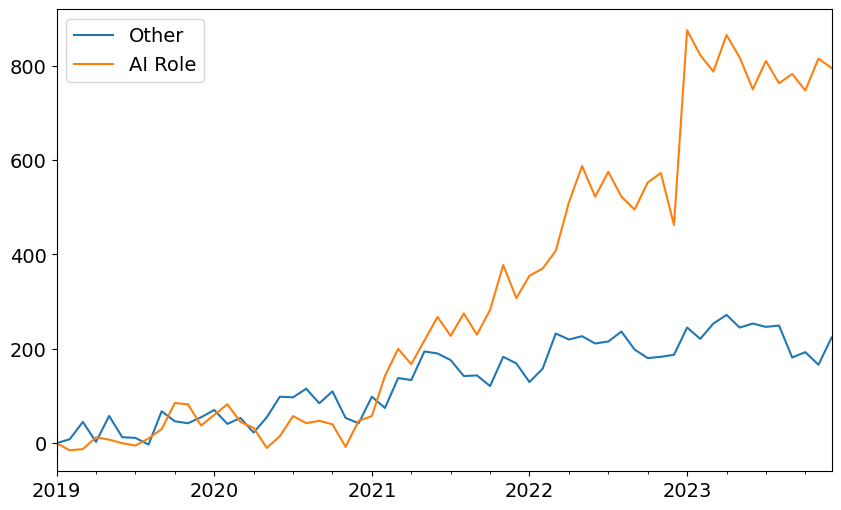

In [30]:
fig, ax = plt.subplots(figsize = (10, 6))
normalized_data.plot(ax = ax, marker = None)
# remove x axis label
plt.xlabel('')


# With Large Sample

In [30]:
usdf.columns

Index(['ID', 'CITY_NAME', 'COUNTY_NAME', 'STATE_NAME', 'NAICS_2022_2',
       'NAICS_2022_2_NAME', 'MIN_EDULEVELS_NAME', 'EMPLOYMENT_TYPE',
       'EMPLOYMENT_TYPE_NAME', 'IS_INTERNSHIP', 'REMOTE_TYPE',
       'REMOTE_TYPE_NAME', 'SKILLS', 'SKILLS_NAME', 'POSTED',
       'LAST_UPDATED_DATE', 'ONET', 'ONET_NAME', 'ONET_2019', 'ONET_2019_NAME',
       'SOC_2021_2_NAME', 'SOC_2021_2', 'MIN_YEARS_EXPERIENCE', 'COMPANY',
       'COMPANY_NAME', 'COMPANY_RAW', 'SALARY', 'EXPIRED', 'DURATION',
       'AI ROLE', 'wfh_wham_prob', 'wfh_wham', 'YEAR', 'EDU_ASSISTANCE',
       'PAID LEAVE', 'WELLBEING', 'HEALTH_WELLBEING', 'PARENTAL_LEAVE',
       'CULTURE', 'QUARTER'],
      dtype='object')

In [13]:
usdf.groupby('QUARTER')['ID'].count()

QUARTER
2018Q1    250438
2018Q2    316730
2018Q3    347028
2018Q4    347315
2019Q1    315932
2019Q2    310043
2019Q3    338733
2019Q4    350333
2020Q1    380107
2020Q2    296386
2020Q3    334185
2020Q4    318436
2021Q1    375252
2021Q2    450058
2021Q3    410074
2021Q4    434136
2022Q1    482472
2022Q2    496059
2022Q3    467684
2022Q4    405561
2023Q1    401299
2023Q2    393495
2023Q3    374026
2023Q4    316975
2024Q1    355647
2024Q2    356051
Freq: Q-DEC, Name: ID, dtype: int64

In [8]:
quarterly_postings = usdf.groupby(['QUARTER', 'AI ROLE']).size().reset_index(name = 'COUNT')

In [9]:
pivot_data = quarterly_postings.pivot(index = 'QUARTER', columns = 'AI ROLE', values = 'COUNT').fillna(0)

In [10]:
pivot_data

AI ROLE,False,True
QUARTER,,
2018Q1,247395,3043
2018Q2,313199,3531
2018Q3,342968,4060
2018Q4,342865,4450
2019Q1,311716,4216
2019Q2,305798,4245
2019Q3,334243,4490
2019Q4,345483,4850
2020Q1,375221,4886


In [11]:
pivot_data.columns = ['Other', 'AI Role']

In [12]:
baseline = pivot_data.loc['2018Q1']

In [13]:
baseline

Other      247395
AI Role      3043
Name: 2018Q1, dtype: int64

In [14]:
normalized_data = ((pivot_data - baseline) / baseline)*100

In [58]:
# normalized_data = (pivot_data/baseline)*100

In [22]:
normalized_data

,Other,AI Role
QUARTER,,
2018Q1,0.000000,0.000000
2018Q2,26.598759,16.036806
2018Q3,38.631743,33.420966
2018Q4,38.590109,46.237266
2019Q1,25.999313,38.547486
2019Q2,23.607187,39.500493
2019Q3,35.104994,47.551758
2019Q4,39.648336,59.382189
2020Q1,51.668789,60.565232


In [59]:
if normalized_data.iloc[-1, 0] < -90: 
    normalized_data = normalized_data.drop(normalized_data.index[-1])

In [23]:
normalized_data.drop(normalized_data.index[-1], inplace = True)

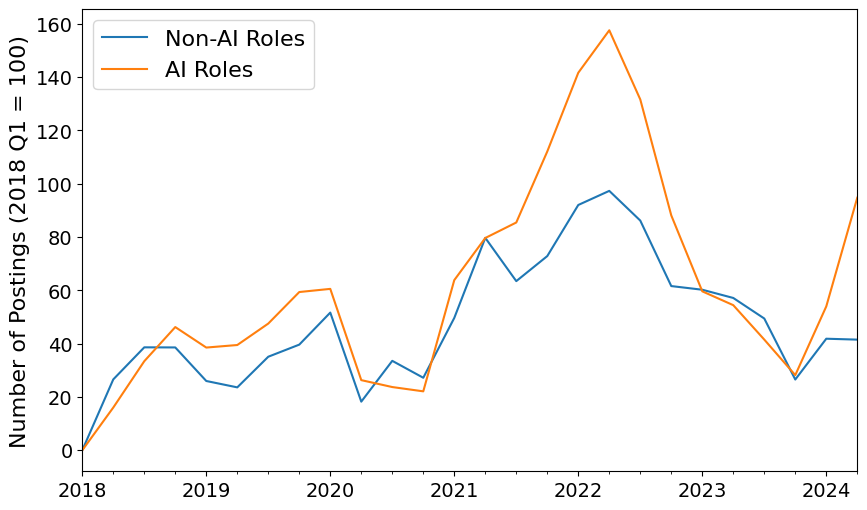

In [24]:
fig, ax = plt.subplots(figsize = (10, 6))
normalized_data.plot(ax = ax, marker = None)
ax.set_xlabel('Quarter')
# Set the labels and title
ax.set_xlabel(None)
ax.set_ylabel('Number of Postings (2018 Q1 = 100)', fontsize=16)
ax.legend(title=None, labels = ['Non-AI Roles', 'AI Roles'], fontsize = 16)
plt.savefig('../figures/job growth/quarterly_postings_2024.png')

## By Year

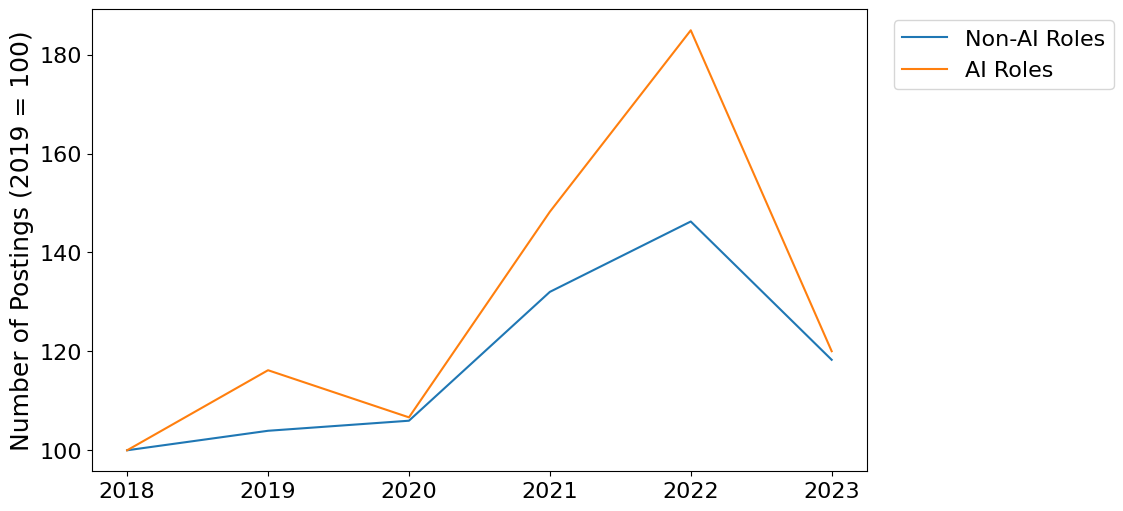

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by year and AI skills, then count the number of jobs
grouped_data = usdf.groupby(['YEAR', 'AI ROLE']).size().reset_index(name='count')

# Pivot the data to get AI skills as separate columns
pivot_data = grouped_data.pivot(index='YEAR', columns='AI ROLE', values='count').fillna(0)

# Rename the columns to "AI skills" and "Other"
pivot_data.columns = ['Other', 'AI Roles']

# Calculate the baseline (average number of postings in 2019)
baseline = pivot_data.loc[2018]

# Normalize the data
normalized_data = (pivot_data / baseline) * 100
normalized_data = normalized_data.loc[2018:2023]

# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the normalized data as a time series line plot
normalized_data.plot(ax=ax, marker=None, fontsize = 16)

# Set the labels and title
ax.set_xlabel(None)
ax.set_ylabel('Number of Postings (2019 = 100)', fontsize=18)
# ax.set_title('Indexed Number of Remote Work Jobs Over Time (2019 = 100)', fontsize=16)

# Set the x-ticks to show whole years
ax.set_xticks(normalized_data.index)
ax.set_xticklabels(normalized_data.index.astype(int))

# Add a legend
ax.legend(title=None, labels = ['Non-AI Roles', 'AI Roles'], bbox_to_anchor=(1.02, 1), loc='upper left', fontsize = 16)

# Show the plot
plt.show()


In [11]:
grouped_data

,YEAR,AI ROLE,count
0,2018,False,1617510
1,2018,True,19800
2,2019,False,1681277
3,2019,True,23005
4,2020,False,1714180
5,2020,True,21118
6,2021,False,2135547
7,2021,True,29349
8,2022,False,2365724
9,2022,True,36614


In [12]:
19800/(19800 + 1617510)

0.012093006211407737

In [38]:
normalized_data

,Other,AI Roles
YEAR,,
2018,100.000000,100.000000
2019,104.258133,108.982456
2020,105.981991,107.859649
2021,131.516995,157.684211
2022,146.275655,178.385965
2023,118.398637,113.473684
2024,29.084936,28.912281


In [41]:
# filter starting from 2019
normalized_data = normalized_data.loc[2019:2023]


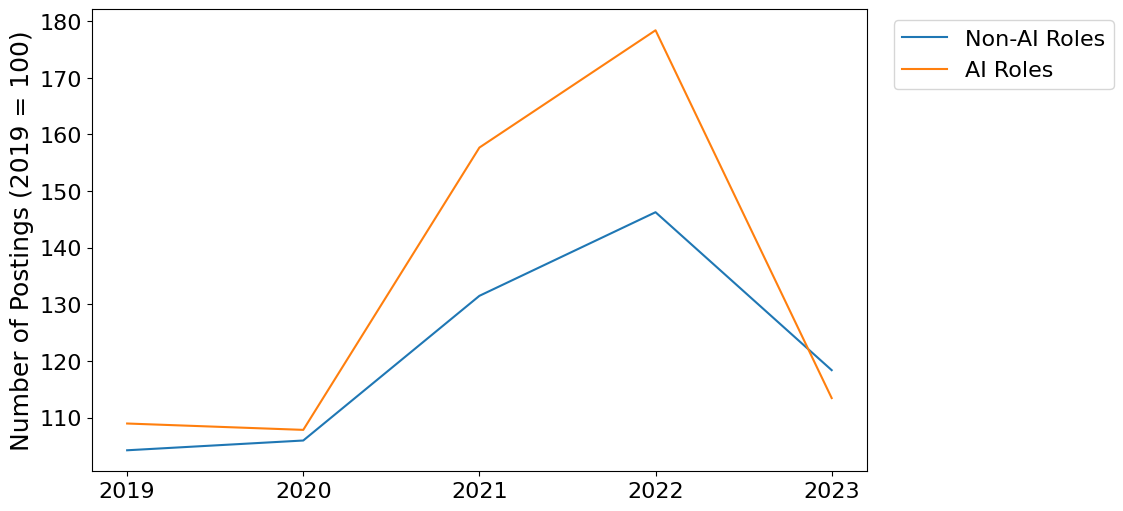

In [42]:
# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the normalized data as a time series line plot
normalized_data.plot(ax=ax, marker=None, fontsize = 16)

# Set the labels and title
ax.set_xlabel(None)
ax.set_ylabel('Number of Postings (2019 = 100)', fontsize=18)
# ax.set_title('Indexed Number of Remote Work Jobs Over Time (2019 = 100)', fontsize=16)

# Set the x-ticks to show whole years
ax.set_xticks(normalized_data.index)
ax.set_xticklabels(normalized_data.index.astype(int))

# Add a legend
ax.legend(title=None, labels = ['Non-AI Roles', 'AI Roles'], bbox_to_anchor=(1.02, 1), loc='upper left', fontsize = 16)

# Show the plot
plt.show()

# % AI Roles Over Time 

In [25]:
percent_data = usdf.groupby('QUARTER')['AI ROLE'].mean().reset_index(name = '% AI Roles')

In [26]:
# percent_data.set_index('YEAR', inplace = True)

In [27]:
percent_data['% AI Roles'] = percent_data['% AI Roles']*100

In [28]:
percent_data

,QUARTER,% AI Roles
0,2018Q1,1.215071
1,2018Q2,1.114830
2,2018Q3,1.169934
3,2018Q4,1.281258
4,2019Q1,1.334464
5,2019Q2,1.369165
6,2019Q3,1.325528
7,2019Q4,1.384397
8,2020Q1,1.285428
9,2020Q2,1.296957


In [29]:
industries = usdf[industry].unique()

In [30]:
industries

array(['Administrative and Support and Waste Management and Remediation Services',
       'Unclassified Industry', 'Finance and Insurance',
       'Professional, Scientific, and Technical Services',
       'Health Care and Social Assistance', 'Educational Services',
       'Information', 'Accommodation and Food Services',
       'Arts, Entertainment, and Recreation',
       'Real Estate and Rental and Leasing',
       'Transportation and Warehousing', 'Public Administration',
       'Wholesale Trade', 'Manufacturing', 'Retail Trade',
       'Management of Companies and Enterprises', 'Construction',
       'Utilities', 'Other Services (except Public Administration)',
       'Mining, Quarrying, and Oil and Gas Extraction',
       'Agriculture, Forestry, Fishing and Hunting'], dtype=object)

In [31]:
ind_dfs = []
for ind in industries:
    industry_df = usdf[usdf[industry]==ind]
    industry_pcts = industry_df.groupby('QUARTER')['AI ROLE'].mean().reset_index(name = '% AI Roles')
    ind_dfs.append(industry_pcts)

In [32]:
ind_dfs[0]

,QUARTER,% AI Roles
0,2018Q1,0.009254
1,2018Q2,0.009315
2,2018Q3,0.009597
3,2018Q4,0.010434
4,2019Q1,0.009294
5,2019Q2,0.009103
6,2019Q3,0.009704
7,2019Q4,0.010572
8,2020Q1,0.009816
9,2020Q2,0.010833


In [33]:
ind_df_all = pd.concat(ind_dfs, axis = 0)

In [34]:
ind_df_all

,QUARTER,% AI Roles
0,2018Q1,0.009254
1,2018Q2,0.009315
2,2018Q3,0.009597
3,2018Q4,0.010434
4,2019Q1,0.009294
...,...,...
22,2023Q3,0.001466
23,2023Q4,0.001996
24,2024Q1,0.007680
25,2024Q2,0.006656


In [35]:
avg_ind_year = ind_df_all.groupby('QUARTER')['% AI Roles'].mean().reset_index()

In [36]:
avg_ind_year

,QUARTER,% AI Roles
0,2018Q1,0.011253
1,2018Q2,0.010708
2,2018Q3,0.010921
3,2018Q4,0.011739
4,2019Q1,0.012792
5,2019Q2,0.013037
6,2019Q3,0.013455
7,2019Q4,0.013109
8,2020Q1,0.012820
9,2020Q2,0.012978


In [37]:
avg_ind_year.rename(columns = {'% AI Roles': 'Industry Average'}, inplace = True)

In [38]:
avg_ind_year['Industry Average'] = avg_ind_year['Industry Average']*100

In [39]:
pct_df_all = percent_data.merge(avg_ind_year, on = 'QUARTER')

In [40]:
pct_df_all

,QUARTER,% AI Roles,Industry Average
0,2018Q1,1.215071,1.125296
1,2018Q2,1.114830,1.070806
2,2018Q3,1.169934,1.092094
3,2018Q4,1.281258,1.173908
4,2019Q1,1.334464,1.279157
5,2019Q2,1.369165,1.303687
6,2019Q3,1.325528,1.345466
7,2019Q4,1.384397,1.310917
8,2020Q1,1.285428,1.281983
9,2020Q2,1.296957,1.297793


In [41]:
pct_df_all.set_index('QUARTER', inplace = True)

In [ ]:
pct_df_all.drop(pct_df_all.index[-1], inplace = True)

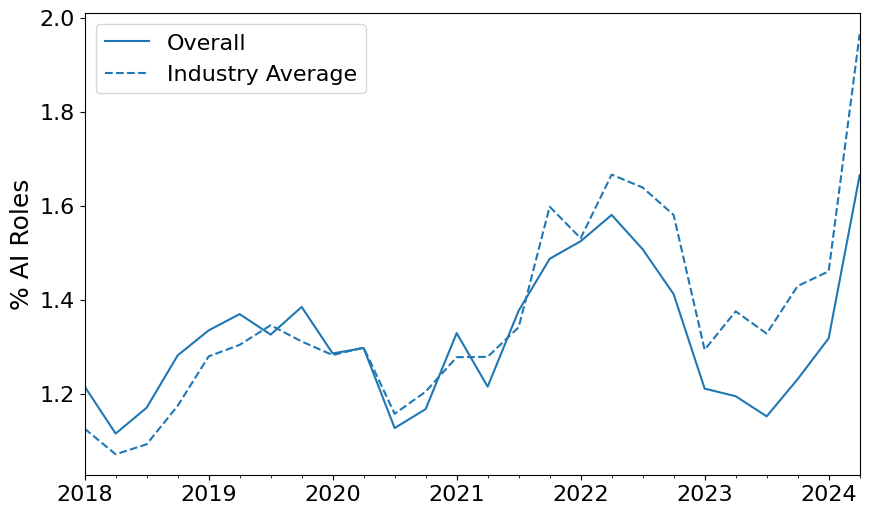

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot all data
pct_df_all.plot(ax=ax, marker=None, fontsize=16)

# Set the color of the industry average line to match the '% AI Roles' line and set it as dotted
ai_roles_line = ax.lines[pct_df_all.columns.get_loc('% AI Roles')]  # Get the '% AI Roles' line
industry_avg_line = ax.lines[pct_df_all.columns.get_loc('Industry Average')]  # Get the 'Industry Average' line

industry_avg_line.set_linestyle('--')
industry_avg_line.set_color(ai_roles_line.get_color())  # Set industry average line to same color as '% AI Roles'

# Add a legend
ax.legend(title=None, labels=['Overall', 'Industry Average'], bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=16)
# Add a legend inside the plot
ax.legend(title=None, labels=['Overall', 'Industry Average'], loc='upper left', fontsize=16)
# Label adjustments
plt.xlabel(None)
plt.ylabel('% AI Roles', fontsize=18)
# plt.tight_layout()
plt.savefig('../figures/pct_ai_roles_overall_industry.png', bbox_inches = 'tight')
# Show the plot
plt.show()


# Change in Benefits Over Time

In [52]:
even_sample['POSTED'] = pd.to_datetime(even_sample['POSTED'])

In [53]:
even_sample['QUARTER'] = even_sample['POSTED'].dt.to_period('Q')

In [86]:
benefits_labels

('Tuition Assistance',
 'Work-Life Balance',
 'Paid Vacation',
 'Health & Wellbeing',
 'Parental Leave',
 'Inclusive Culture',
 'Remote Work')

In [87]:
# map benefits to benefits labels
benefit_labels_map = {}
for i, benefit in enumerate(benefits):
    benefit_labels_map[benefit] = benefits_labels[i]

In [88]:
benefit_labels_map

{'EDU_ASSISTANCE': 'Tuition Assistance',
 'WLB': 'Work-Life Balance',
 'PAID_LEAVE': 'Paid Vacation',
 'HEALTH_WELLBEING': 'Health & Wellbeing',
 'PARENTAL_LEAVE': 'Parental Leave',
 'CULTURE': 'Inclusive Culture',
 'wfh_wham': 'Remote Work'}

In [23]:
def count_benefits(data, benefit, period):
    """
    Plot the benefits for AI and non AI roles over time.

    Parameters:
    - data: a DataFrame containing the benefits of remote work over time
    - benefit: the benefit to plot

    Returns:
    - None
    """
    
    grouped_data = data.groupby([period, 'AI ROLE', benefit]).size().reset_index(name='count')


    # Calculate the total number of jobs per month for each AI skill category
    total_monthly_jobs = grouped_data.groupby([period, 'AI ROLE'])['count'].sum().reset_index(name='total_count')

    # Filter for benefit
    benefit_jobs = grouped_data[grouped_data[benefit] == 1]
    benefit_monthly_jobs = benefit_jobs.groupby([period, 'AI ROLE'])['count'].sum().reset_index(name='benefit_count')

    # Merge the total monthly jobs with the remote jobs data
    merged_data = pd.merge(benefit_monthly_jobs, total_monthly_jobs, on=[period, 'AI ROLE'])
    merged_data['percentage'] = (merged_data['benefit_count'] / merged_data['total_count']) * 100
    # display(merged_data)
    return merged_data



def plot_benefits(merged_data, benefit, period):
    pivot_data = merged_data.pivot(index = period, columns = 'AI ROLE', values = 'percentage').fillna(0)
    # Create a figure and axis object
    fig, ax = plt.subplots(figsize=(10, 6))

    pivot_data.plot(ax = ax)
    ax.set_xlabel(None)
    ax.set_ylabel('Percent Jobs with Benefit')
    ax.legend(['Other', 'AI Role'])
    ax.set_title(benefit_labels_map[benefit])
    ax.set_ylim(0, 50)
    plt.savefig(f'../figures/over_time_{benefit}_2.png')
 
    # Show the plot
    plt.show()

In [90]:
even_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,WELLBEING,HEALTH_WELLBEING,RECOGNITION,FAMILY,PARENTAL_LEAVE,CULTURE,EXPERIENCE_BUCKET,LOG_SALARY,YEARMONTH,QUARTER
0,b320dcdab94034000293d0c979dafd03543b828b,"San Jose, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,True,3-5 years,12.177416,2023-03,2023Q1
1,39036fb07ef90297a94c281b153ee88c6d71c514,"Memphis, TN","Shelby, TN",Tennessee,54,"Professional, Scientific, and Technical Services",Master's degree,1,Full-time (> 32 hours),False,...,False,True,False,False,False,False,6-10 years,11.813585,2022-08,2022Q3
2,a81d1896d80873ed098d16225633e2c085c38b5b,"Detroit, MI","Wayne, MI",Michigan,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,None Listed,11.169900,2022-05,2022Q2
3,1031387a0b167843c4eba97e3d239c9aed4c7e19,"Grand Rapids, MI","Kent, MI",Michigan,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,11.670356,2022-10,2022Q4
4,85e918411cbf9017505845fb6b9aced339507afb,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,1-2 years,11.407565,2019-09,2019Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,a52ad16f54d407bdd566fff339ce0538584793f6,"Albany, OR","Linn, OR",Oregon,52,Finance and Insurance,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,None Listed,10.635855,2021-03,2021Q1
19996,47eead071d7aa1bb7f3e11e10476688deb22e324,"Lithia Springs, GA","Douglas, GA",Georgia,56,Administrative and Support and Waste Managemen...,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,10.551899,2021-08,2021Q3
19997,20de39afaee660a555b7d99e8142f5f3906f0a29,"Lufkin, TX","Angelina, TX",Texas,44,Retail Trade,No Education Listed,3,Part-time / full-time,False,...,True,True,False,True,True,False,None Listed,10.097573,2021-06,2021Q2
19998,561636d55907d615dcdb24a4ae8fd2777829e767,"Scottsdale, AZ","Maricopa, AZ",Arizona,72,Accommodation and Food Services,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,1-2 years,10.544288,2022-03,2022Q1


In [56]:
even_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,WLB,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,EXPERIENCE_BUCKET,SALARY,LOG_SALARY,Remote_KW,QUARTER
0,c24b748985411eb72c35c6bd0858ca3317043224,"Arlington, VA","Arlington, VA",Virginia,92,Public Administration,Bachelor's degree,3,Part-time / full-time,False,...,False,False,True,False,False,1-2 years,66425.0,11.103829,1,2019Q4
1,648ef7de9588114c53107fb5c990cd0b176e4a8f,"Irving, TX","Dallas, TX",Texas,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,6-10 years,186000.0,12.133502,0,2023Q2
2,41116976922260bb94ac44092bb578e246eb3bb6,"Charlotte, NC","Mecklenburg, NC",North Carolina,56,Administrative and Support and Waste Managemen...,High school or GED,1,Full-time (> 32 hours),False,...,False,False,False,False,False,11-20 years,133120.0,11.799006,0,2022Q3
3,d8d796257493113fb722989284ce9d34d2eeb49a,"Irvine, CA","Orange, CA",California,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,True,True,False,False,False,3-5 years,95000.0,11.461632,1,2022Q2
4,35f59149dae5bd4c84a6048396f0012364d80ecb,"Seattle, WA","King, WA",Washington,99,Unclassified Industry,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,11-20 years,177500.0,12.086726,0,2022Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,f7ce9b566eac93c68895de07dc6a5b2835a435e5,"Boulder, CO","Boulder, CO",Colorado,56,Administrative and Support and Waste Managemen...,High school or GED,2,Part-time (≤ 32 hours),False,...,True,True,False,False,False,0 years,39260.0,10.577961,0,2022Q2
19996,2886e022925e32150a9e93d339f2452d9ed70820,"Wilmer, TX","Dallas, TX",Texas,31,Manufacturing,High school or GED,1,Full-time (> 32 hours),False,...,False,False,False,False,False,None Listed,31200.0,10.348173,0,2019Q3
19997,594d7e239ad01aba75d662ffa8159a0d4801458e,"Glenwood Springs, CO","Garfield, CO",Colorado,61,Educational Services,Associate degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,3-5 years,51100.0,10.841540,0,2022Q1
19998,034532180741817cd619ee069a93b1fa6635a449,"Los Angeles, CA","Los Angeles, CA",California,54,"Professional, Scientific, and Technical Services",Bachelor's degree,1,Full-time (> 32 hours),False,...,True,True,False,True,False,None Listed,45000.0,10.714418,1,2021Q3


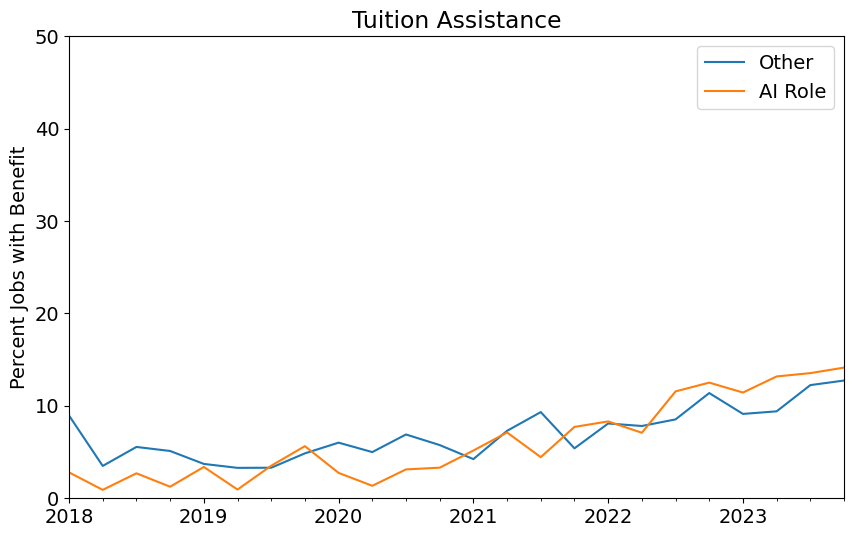

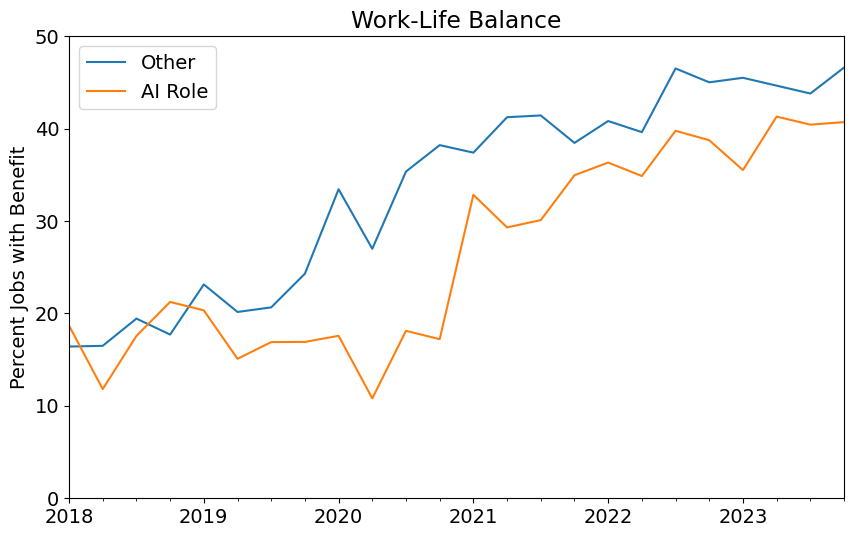

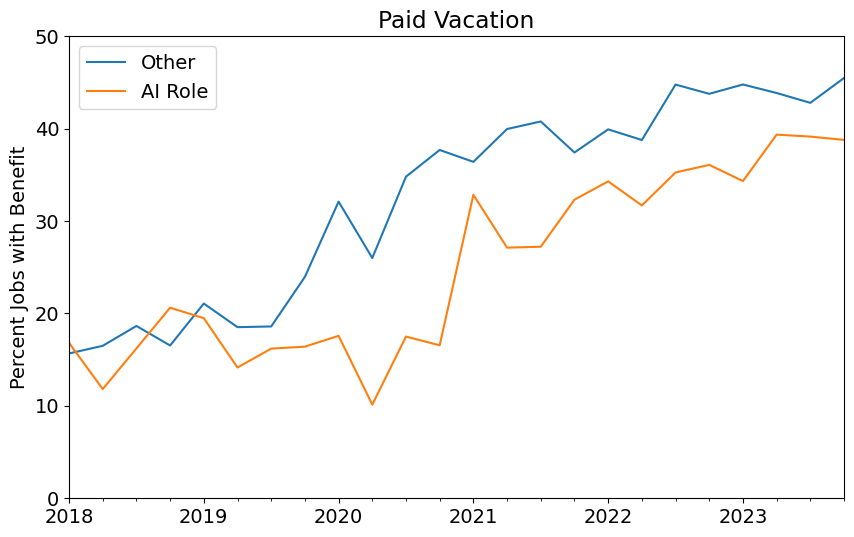

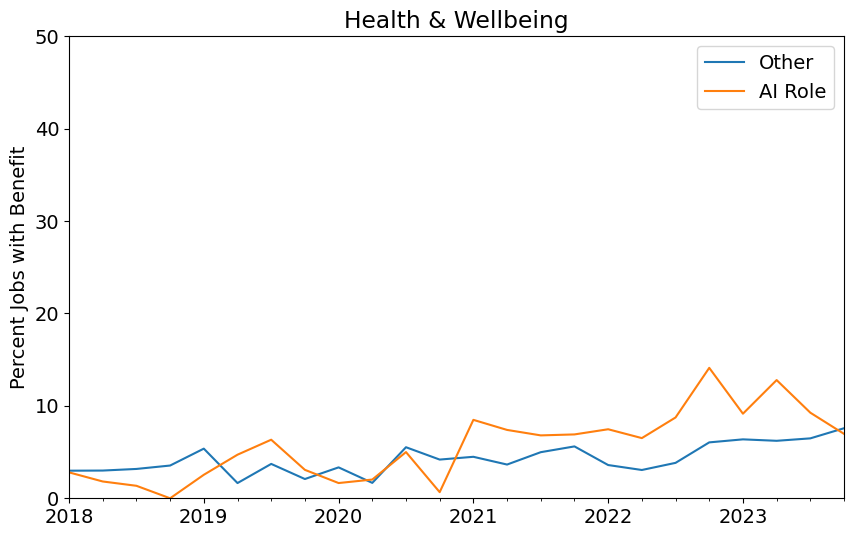

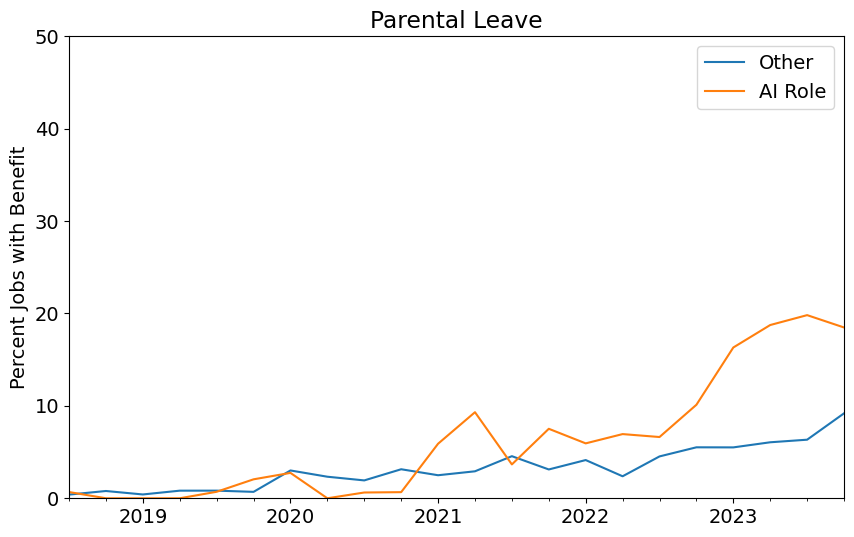

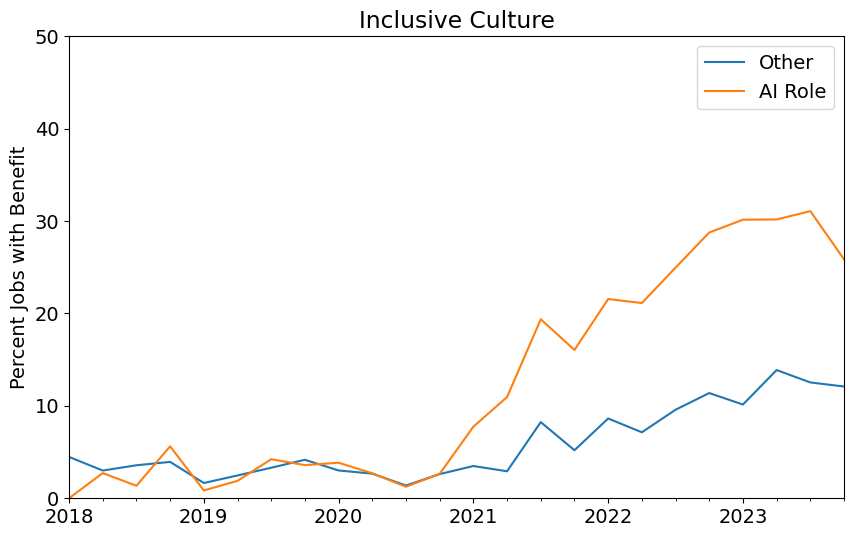

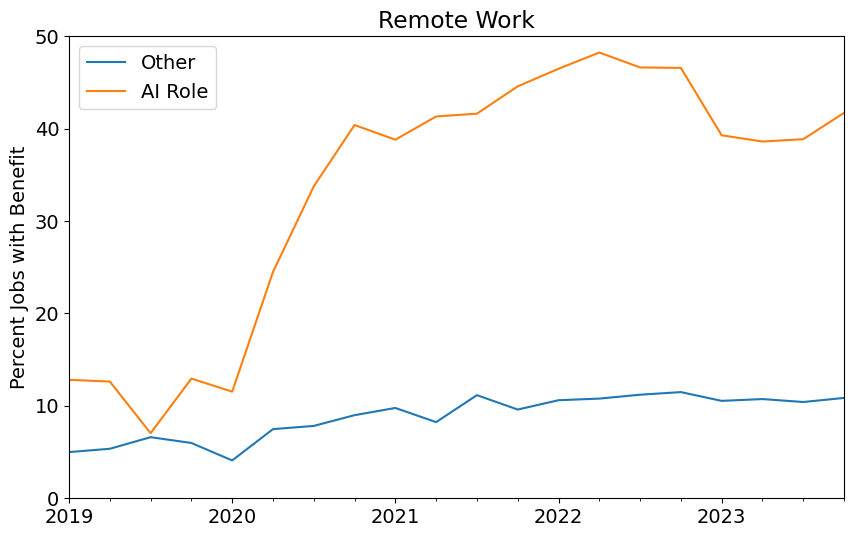

In [93]:
for benefit in benefits:
    merged_data = count_benefits(even_sample, benefit, 'QUARTER')
    plot_benefits(merged_data, benefit, 'QUARTER')

In [ ]:


# Convert 'POSTED' column to datetime
usdf['POSTED'] = pd.to_datetime(usdf['POSTED'])

# Group by date and AI skills, then count the number of jobs
grouped_data = usdf.groupby(['POSTED', 'Has AI Skills', 'wfh_wham']).size().reset_index(name='count')

# Resample by month
grouped_data['POSTED'] = grouped_data['POSTED'].dt.to_period('M')

# Calculate the total number of jobs per month for each AI skill category
total_monthly_jobs = grouped_data.groupby(['POSTED', 'Has AI Skills'])['count'].sum().reset_index(name='total_count')

# Filter for remote work jobs
remote_jobs = grouped_data[grouped_data['wfh_wham'] == 1]
remote_monthly_jobs = remote_jobs.groupby(['POSTED', 'Has AI Skills'])['count'].sum().reset_index(name='remote_count')

# Merge the total monthly jobs with the remote jobs data
merged_data = pd.merge(remote_monthly_jobs, total_monthly_jobs, on=['POSTED', 'Has AI Skills'])





In [ ]:

# Calculate the percentage of remote jobs for each AI skills category per month
merged_data['percentage'] = (merged_data['remote_count'] / merged_data['total_count']) * 100

# Convert 'POSTED' back to datetime for plotting
merged_data['POSTED'] = merged_data['POSTED'].dt.to_timestamp()

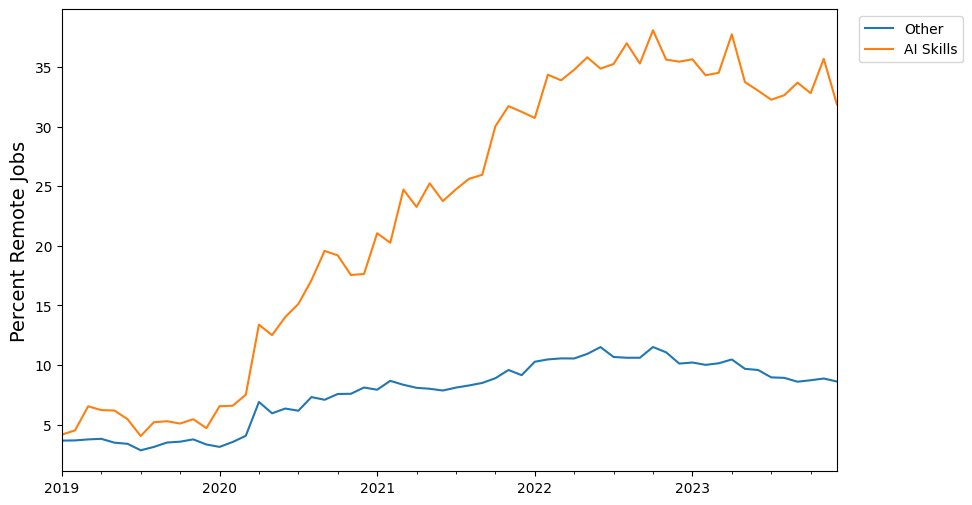

In [ ]:
# Pivot the data to get AI skills as separate columns for percentages
pivot_data = merged_data.pivot(index='POSTED', columns='Has AI Skills', values='percentage').fillna(0)

# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data as a time series line plot
pivot_data.plot(ax=ax)

# Set the labels and title
ax.set_xlabel(None)
ax.set_ylabel('Percent Remote Jobs', fontsize=14)
# ax.set_title('Percentage of Remote Work Jobs Over Time', fontsize=16)

# Add a legend
ax.legend(['Other','AI Skills'], bbox_to_anchor=(1.02, 1), loc='upper left')

# Show the plot
plt.show()

## Single Line per Benefit

In [24]:
def count_benefits(data, benefit, period):
    """
    Plot the benefits for AI and non AI roles over time.

    Parameters:
    - data: a DataFrame containing the benefits of remote work over time
    - benefit: the benefit to plot

    Returns:
    - None
    """
    
    grouped_data = data.groupby([period, 'AI ROLE', benefit]).size().reset_index(name='count')


    # Calculate the total number of jobs per month for each AI skill category
    total_monthly_jobs = grouped_data.groupby([period, 'AI ROLE'])['count'].sum().reset_index(name='total_count')

    # Filter for benefit
    benefit_jobs = grouped_data[grouped_data[benefit] == 1]
    benefit_monthly_jobs = benefit_jobs.groupby([period, 'AI ROLE'])['count'].sum().reset_index(name='benefit_count')

    # Merge the total monthly jobs with the remote jobs data
    merged_data = pd.merge(benefit_monthly_jobs, total_monthly_jobs, on=[period, 'AI ROLE'])
    merged_data['percentage'] = (merged_data['benefit_count'] / merged_data['total_count']) * 100
    # display(merged_data)
    return merged_data


In [25]:
all_quarters = usdf['QUARTER'].unique()

In [39]:
merged_data = count_benefits(usdf, 'PARENTAL_LEAVE', 'QUARTER')

In [41]:
1.209677-0.844679

0.36499799999999993

In [40]:
merged_data

,QUARTER,AI ROLE,benefit_count,total_count,percentage
0,2018Q1,False,930,247395,0.375917
1,2018Q1,True,26,3043,0.854420
2,2018Q2,False,1396,313199,0.445723
3,2018Q2,True,44,3531,1.246106
4,2018Q3,False,1644,342968,0.479345
5,2018Q3,True,34,4060,0.837438
6,2018Q4,False,2135,342865,0.622694
7,2018Q4,True,47,4450,1.056180
8,2019Q1,False,2633,311716,0.844679
9,2019Q1,True,51,4216,1.209677


In [26]:
def get_percent_diffs(benefits, data):
    pct_diff_df = pd.DataFrame(all_quarters).set_index(0)
    # pct_diff_df.index = pct_diff_df.index.astype(str)
    for benefit in benefits:
        merged_data = count_benefits(data, benefit, 'QUARTER')
        pivot_data = merged_data.pivot(index = 'QUARTER', columns = 'AI ROLE', values = 'percentage').fillna(0)
        pivot_data.columns = ['Other', 'AI Role']
        pivot_data['pct_diff'] = pivot_data['AI Role'] - pivot_data['Other']
        print(pivot_data.index.dtype)
        print(pct_diff_df.index.dtype)
        # pivot_data_index = pivot_data.index.astype(str)
        pivot_data = pivot_data.reindex(pct_diff_df.index).fillna(0)
        pct_diff_df[benefit] = pivot_data['pct_diff']
    return pct_diff_df
        
        

In [27]:
percent_diffs = get_percent_diffs(benefits4, usdf)

period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]


In [25]:
benefit_colors.values()

dict_values(['#41afaa', '#466eb4', '#e6a532', '#00a0e1', '#d7642c', '#af4b91'])

In [28]:
percent_diffs.sort_index(inplace = True)

In [29]:
percent_diffs

,EDU_ASSISTANCE,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,REMOTE_KW
0,,,,,,
2018Q1,-0.677355,-1.949745,-0.947275,0.478503,4.184613,0.844912
2018Q2,-0.428138,-2.297088,-0.540842,0.800383,4.251145,0.823910
2018Q3,-1.404748,-4.794050,-0.588906,0.358093,3.443087,0.965617
2018Q4,-1.336572,-3.621954,-0.589804,0.433486,4.961447,0.232911
2019Q1,-1.524865,-4.689788,-0.174755,0.364998,4.461377,0.681416
2019Q2,-1.758683,-5.641469,-0.442589,0.426804,4.283825,1.029557
2019Q3,-1.953412,-5.611281,-0.728894,0.850045,4.436383,1.828701
2019Q4,-1.950967,-6.992534,-0.804315,0.762997,5.224853,0.144120
2020Q1,-1.963523,-8.021370,-0.932210,0.878970,5.897972,1.805339


<Axes: xlabel='0'>

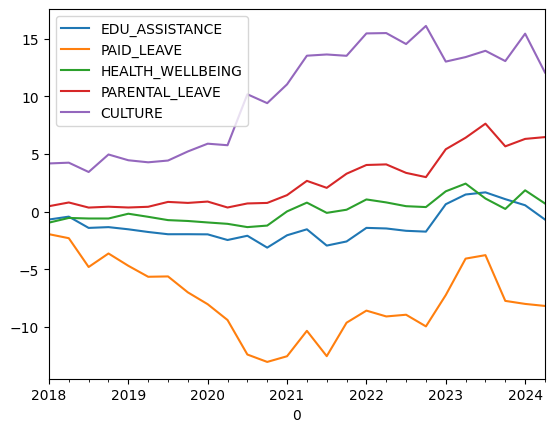

In [51]:
percent_diffs.plot()

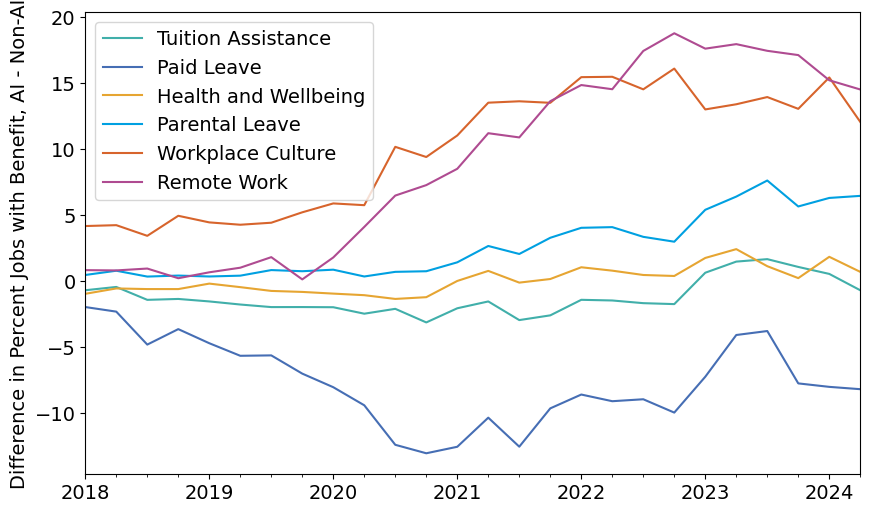

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
percent_diffs.plot(ax = ax, color = benefit_colors.values())
ax.set_xlabel(None)
# ax.set_xticks(range(len(percent_diffs)))
ax.set_ylabel('Difference in Percent Jobs with Benefit, AI - Non-AI')
ax.legend(benefits4_labels)
plt.savefig('../figures/benefits over time/benefit_diffs_time.png')

In [57]:
def get_percent_ratios(benefits, data):
    pct_diff_df = pd.DataFrame(all_quarters).set_index(0)
    # pct_diff_df.index = pct_diff_df.index.astype(str)
    for benefit in benefits:
        merged_data = count_benefits(data, benefit, 'QUARTER')
        pivot_data = merged_data.pivot(index = 'QUARTER', columns = 'AI ROLE', values = 'percentage').fillna(0)
        pivot_data.columns = ['Other', 'AI Role']
        pivot_data['pct_diff'] = pivot_data['AI Role'] / pivot_data['Other']
        print(pivot_data.index.dtype)
        print(pct_diff_df.index.dtype)
        # pivot_data_index = pivot_data.index.astype(str)
        pivot_data = pivot_data.reindex(pct_diff_df.index).fillna(0)
        pct_diff_df[benefit] = pivot_data['pct_diff']
    return pct_diff_df
        
        

In [58]:
pct_ratios = get_percent_ratios(benefits5, usdf)

period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]
period[Q-DEC]


In [62]:
pct_ratios.sort_index(inplace = True)

In [63]:
pct_ratios

,EDU_ASSISTANCE,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE
0,,,,,
2018Q1,0.872460,0.805045,0.548370,2.272895,1.945609
2018Q2,0.890546,0.780255,0.735120,2.795696,2.088590
2018Q3,0.619865,0.572823,0.745398,1.747047,1.816476
2018Q4,0.651113,0.693100,0.748228,1.696146,2.025875
2019Q1,0.639414,0.644847,0.935011,1.432115,1.904686
2019Q2,0.589025,0.563375,0.836325,1.454284,1.837426
2019Q3,0.598972,0.608138,0.751552,1.870737,1.797392
2019Q4,0.617878,0.557918,0.734648,1.698285,1.899894
2020Q1,0.616153,0.519656,0.668858,1.670477,2.026172


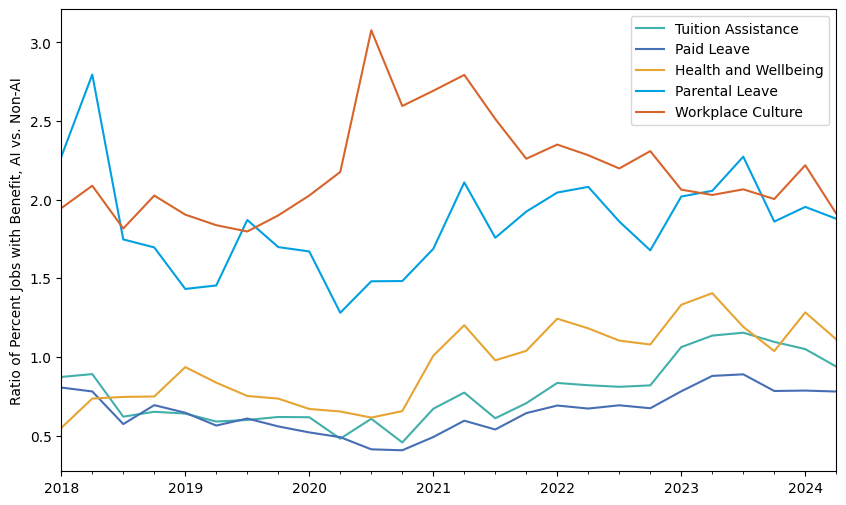

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))
pct_ratios.plot(ax = ax, color = benefit_colors.values())
ax.set_xlabel(None)
# ax.set_xticks(range(len(percent_diffs)))
ax.set_ylabel('Ratio of Percent Jobs with Benefit, AI vs. Non-AI')
ax.legend(benefits4_labels[:-1])
plt.savefig('../figures/benefits over time/benefit_ratios_time.png')

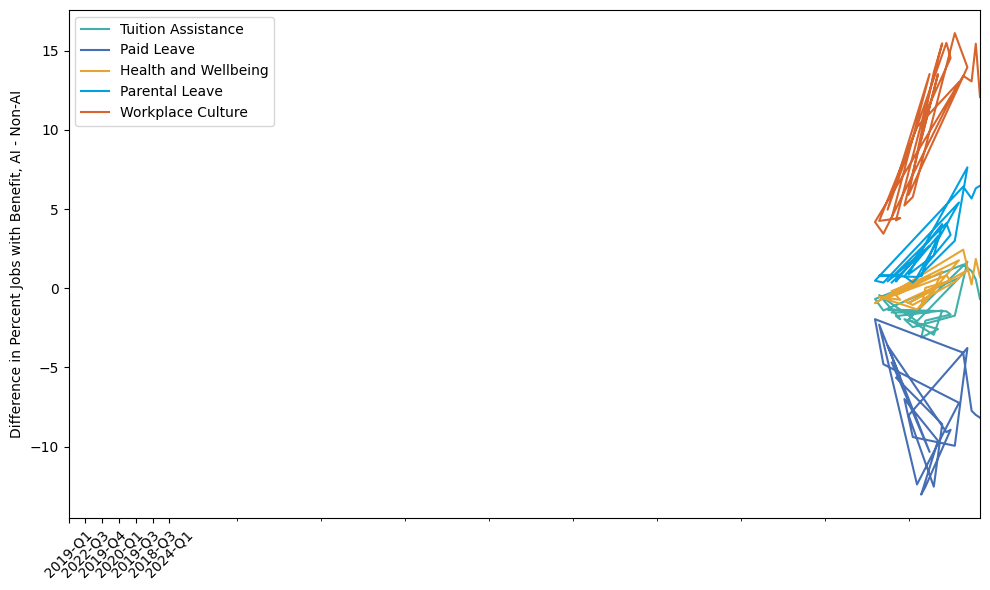

In [34]:
# Convert the QUARTER index to a PeriodIndex to ensure chronological ordering
percent_diffs.index = pd.PeriodIndex(percent_diffs.index, freq='Q')

# Now plot the data
fig, ax = plt.subplots(figsize=(10, 6))
percent_diffs.plot(ax=ax, color=benefit_colors.values())

# Set x-ticks to show quarters at regular intervals (e.g., every 4th quarter)
ax.set_xticks(range(0, len(percent_diffs), 4))
ax.set_xticklabels(percent_diffs.index[::4].strftime('%Y-Q%q'), rotation=45)  # Format as Year-Quarter

# Set axis labels
ax.set_xlabel(None)
ax.set_ylabel('Difference in Percent Jobs with Benefit, AI - Non-AI')

# Update legend with the correct labels
ax.legend(benefits4_labels)

plt.tight_layout()
plt.savefig('../figures/benefits over time/benefit_diffs_time.png')
plt.show()


In [20]:
pd.DataFrame(all_quarters).set_index(0)

""
0
2019Q1
2021Q2
2018Q4
2022Q2
2022Q3
2021Q1
2020Q4
2021Q4
2019Q4


In [12]:
def calculate_benefit_differences(data, benefits, period):
    benefit_differences = {}
    for benefit in benefits:
        # Generate merged_data for each benefit
        merged_data = count_benefits(data, benefit, period)
        
        # Pivot for AI Role difference calculation
        pivot_df = merged_data.pivot(index=period, columns='AI ROLE', values='percentage').fillna(0)
        pivot_df.columns = ['percentage_false', 'percentage_true']
        pivot_df = pivot_df.reindex(all_quarters)
        pivot_df.fillna(0, inplace=True)
        
        # Calculate percentage difference and store it
        pivot_df['percentage_difference'] = pivot_df['percentage_true'] - pivot_df['percentage_false']
        benefit_differences[benefit] = pivot_df['percentage_difference']
    
    return pd.DataFrame(benefit_differences)

def plot_benefit_differences(benefit_differences):
    plt.figure(figsize=(12, 8))
    
    # Plot each benefit's percentage difference
    for benefit, diff_series in benefit_differences.items():
        plt.plot(diff_series, label=benefits_labels_map.get(benefit, benefit))
    
    # Add plot details
    plt.xlabel('Quarter')
    plt.ylabel('Percentage Difference (AI vs Non-AI)')
    plt.title('Percentage Difference of Benefits for AI and Non-AI Roles Over Time')
    plt.legend(loc='upper left')
    plt.ylim(-20, 50)  # Adjust based on your data range
    plt.grid(True)
    plt.savefig('../figures/percentage_difference_all_benefits.png')
    plt.show()

In [36]:
calculate_benefit_differences(usdf, benefits5, 'QUARTER')

,EDU_ASSISTANCE,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE
QUARTER,,,,,
2019Q1,-1.524865,-4.689788,-0.174755,0.364998,4.461377
2021Q2,-1.525979,-10.327955,0.787898,2.674751,13.527649
2018Q4,-1.336572,-3.621954,-0.589804,0.433486,4.961447
2022Q2,-1.452725,-9.081210,0.805672,4.102224,15.488925
2022Q3,-1.655814,-8.933721,0.478204,3.366722,14.538284
2021Q1,-2.043111,-12.531818,0.026398,1.437604,11.043345
2020Q4,-3.114755,-13.024766,-1.202998,0.761728,9.412952
2021Q4,-2.579714,-9.623659,0.172436,3.295752,13.518085
2019Q4,-1.950967,-6.992534,-0.804315,0.762997,5.224853


TypeError: float() argument must be a string or a real number, not 'Period'

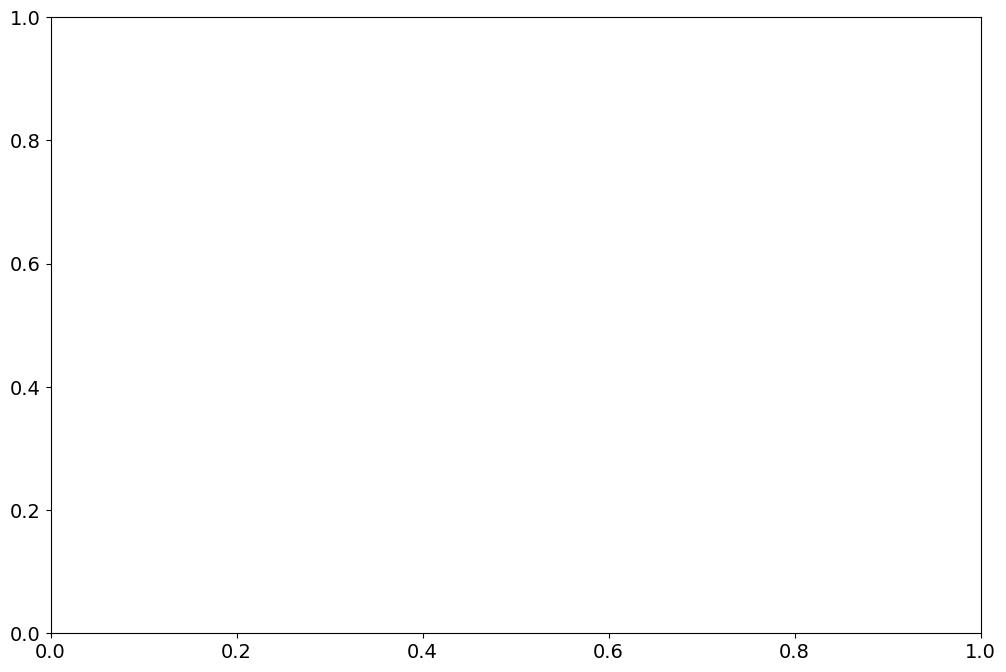

In [42]:

# Calculate benefit differences and plot them
benefit_differences = calculate_benefit_differences(usdf, benefits5, 'QUARTER')
plot_benefit_differences(benefit_differences)

In [50]:
all_quarters = pd.date_range(start='2020Q1', end='2024Q4', freq='QE')

def calculate_benefit_differences(data, benefits, period):
    benefit_differences = {}
    for benefit in benefits:
        # Generate merged_data for each benefit
        merged_data = count_benefits(data, benefit, period)
        
        # Pivot for AI Role difference calculation
        pivot_df = merged_data.pivot(index=period, columns='AI ROLE', values='percentage').fillna(0)
        pivot_df.columns = ['percentage_false', 'percentage_true']
        pivot_df = pivot_df.reindex(all_quarters)
        pivot_df.index = pivot_df.index.astype(str)  # Convert the index to string format
        
        # Calculate percentage difference and store it
        pivot_df['percentage_difference'] = pivot_df['percentage_true'] - pivot_df['percentage_false']
        benefit_differences[benefit] = pivot_df['percentage_difference']
    
    return pd.DataFrame(benefit_differences)

def plot_benefit_differences(benefit_differences):
    plt.figure(figsize=(12, 8))
    
    # Plot each benefit's percentage difference
    for benefit, diff_series in benefit_differences.items():
        plt.plot(diff_series, label=benefits_labels_map.get(benefit, benefit))
    
    # Add plot details
    plt.xlabel('Quarter')
    plt.ylabel('Percentage Difference (AI vs Non-AI)')
    plt.title('Percentage Difference of Benefits for AI and Non-AI Roles Over Time')
    plt.legend(loc='upper left')
    plt.ylim(-20, 50)  # Adjust based on your data range
    plt.grid(True)
    # plt.savefig('../figures/percentage_difference_all_benefits.png')
    plt.show()

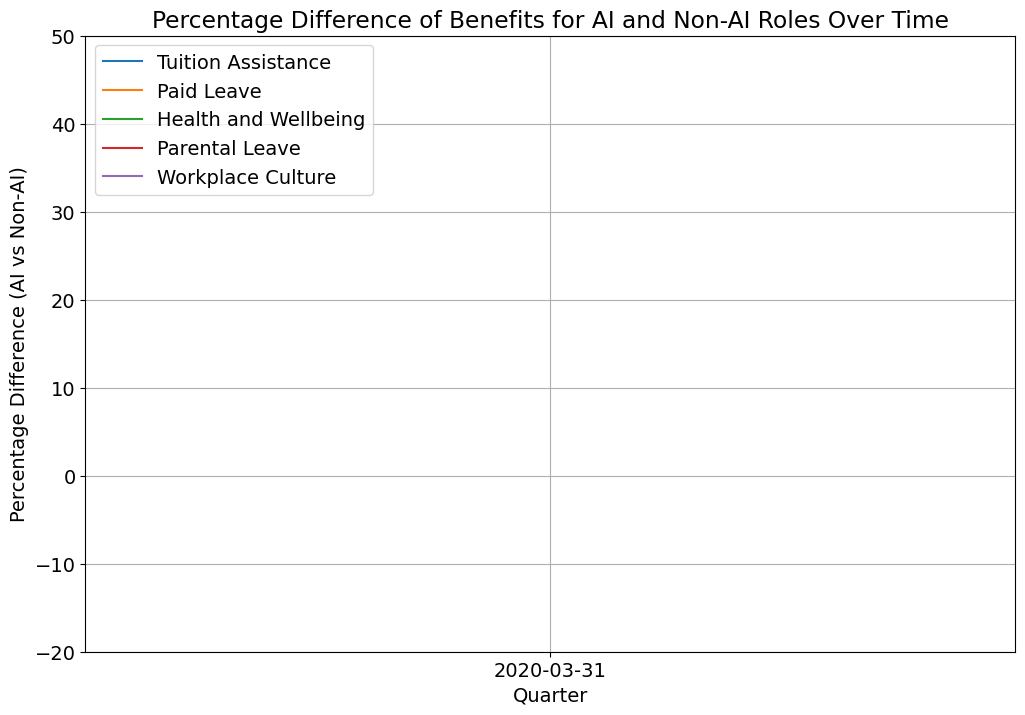

In [52]:
benefit_differences = calculate_benefit_differences(usdf, benefits5, 'QUARTER')
plot_benefit_differences(benefit_differences)

In [ ]:
merged_data.sort_values(by = 'QUARTER', ascending = True)

,QUARTER,AI ROLE,benefit_count,total_count,percentage
0,2018Q3,False,1,252,0.396825
1,2018Q3,True,1,148,0.675676
2,2018Q4,False,2,254,0.787402
3,2019Q1,False,1,242,0.413223
4,2019Q2,False,2,243,0.823045
5,2019Q3,False,2,242,0.826446
6,2019Q3,True,1,142,0.704225
7,2019Q4,False,2,288,0.694444
8,2019Q4,True,4,195,2.051282
9,2020Q1,False,9,299,3.010033


In [ ]:
pivot_df = merged_data.pivot(index='QUARTER', columns='AI ROLE', values='percentage')

# Rename the columns for clarity
pivot_df.columns = ['percentage_false', 'percentage_true']

pivot_df = pivot_df.reindex(all_quarters)

# Fill missing values with NaN or 0 as desired
pivot_df.fillna(0, inplace=True)




In [ ]:
# Calculate the ratio of AI ROLE True to AI ROLE False
pivot_df['ratio_true_to_false'] = pivot_df['percentage_true'] / pivot_df['percentage_false']
pivot_df['percentage_difference'] = pivot_df['percentage_true'] - pivot_df['percentage_false']


In [ ]:
pivot_df

,percentage_false,percentage_true,ratio_true_to_false,percentage_difference
QUARTER,,,,
2018Q3,0.396825,0.675676,1.702703,0.278850
2018Q4,0.787402,NaN,NaN,NaN
2019Q1,0.413223,NaN,NaN,NaN
2019Q2,0.823045,NaN,NaN,NaN
2019Q3,0.826446,0.704225,0.852113,-0.122221
2019Q4,0.694444,2.051282,2.953846,1.356838
2020Q1,3.010033,2.747253,0.912698,-0.262781
2020Q2,2.333333,NaN,NaN,NaN
2020Q3,1.933702,0.625000,0.323214,-1.308702


# Benefits by Company

CAREER_DEV


,COMPANY_RAW,0
0,Jobot,94
1,Guidehouse,93
2,Unknown,80
3,AT&T,38
4,General Motors,34
5,CVS Health,32
6,UnitedHealth Group,30
7,Deloitte,27
8,Lincoln Financial Group,26
9,Booz Allen Hamilton,26


WLB


,COMPANY_RAW,0
0,Unknown,170
1,Jobot,139
2,USAA,98
3,Guidehouse,91
4,CyberCoders,79
5,Elevance Health,51
6,Northrop Grumman,46
7,"Anthem, Inc.",41
8,Amazon,38
9,AT&T,38


WELLBEING


...

,COMPANY_RAW,0
0,Randstad,49
1,General Motors,33
2,"Randstad North America, Inc.",32
3,Randstad US,25
4,Randstad Technologies,17
5,Hudson Group,9
6,Randstad USA,9
7,BAE Systems,8
8,AECOM,6
9,"Spherion Staffing, LLC",4


FAMILY


,COMPANY_RAW,0
0,Guidehouse,92
1,Unknown,36
2,General Motors,33
3,Lincoln Financial Group,26
4,Oracle,26
5,Marriott,23
6,TheCollegeBoard,21
7,Jobot,19
8,TikTok,18
9,Cox,18


CULTURE


,COMPANY_RAW,0
0,Capital One,143
1,Accenture,140
2,Elevance Health,51
3,UnitedHealth Group,45
4,Unknown,34
5,Pearson,32
6,Lincoln Financial Group,29
7,Oracle,24
8,Deloitte,24
9,General Motors,22


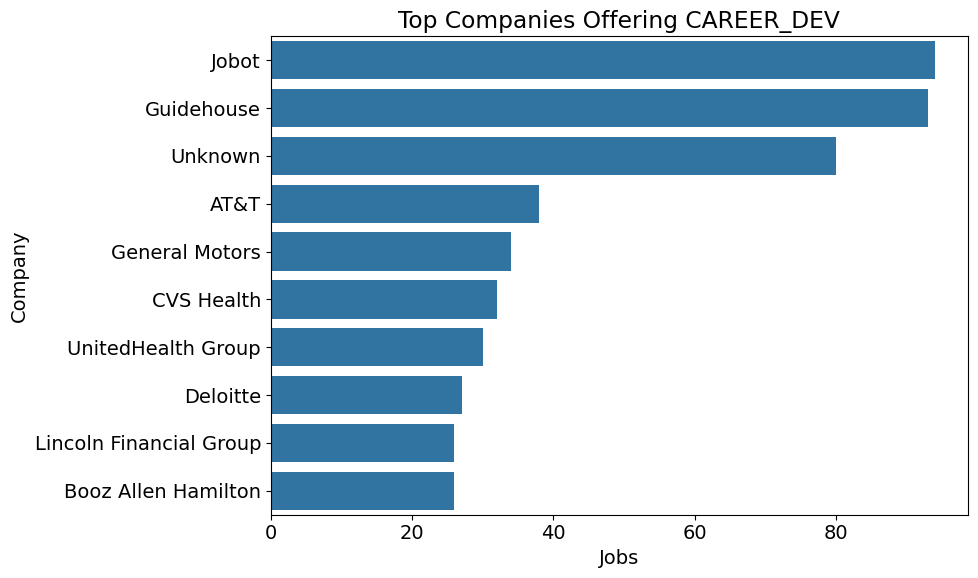

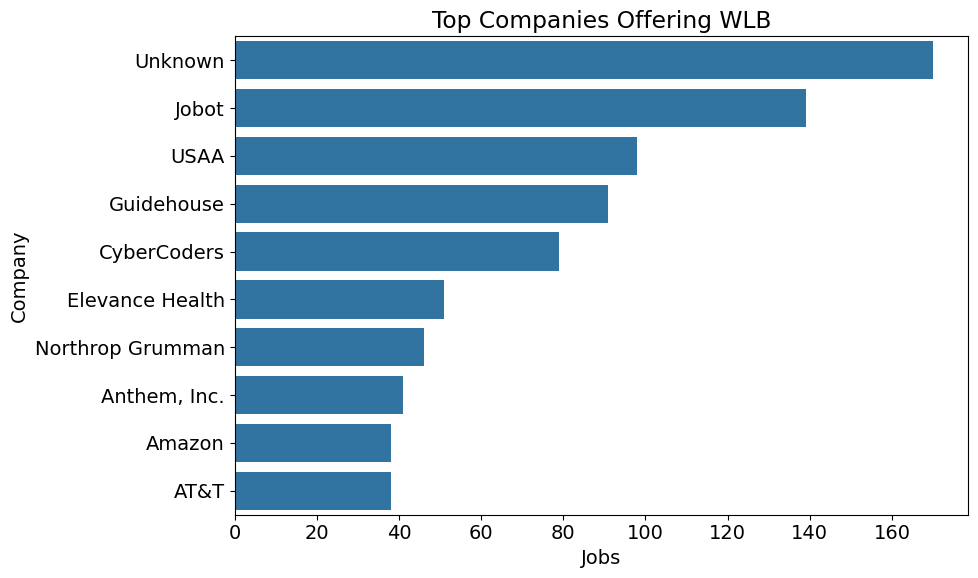

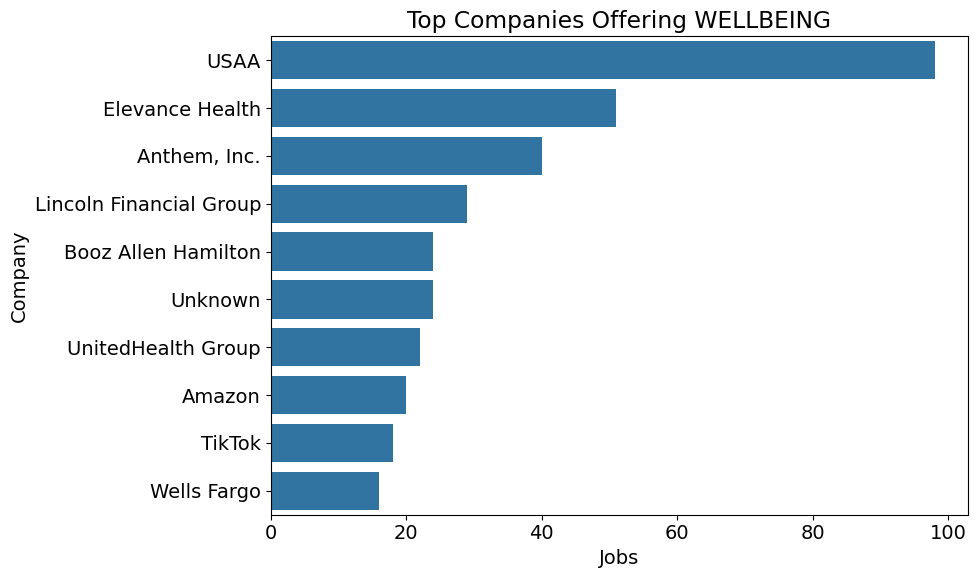

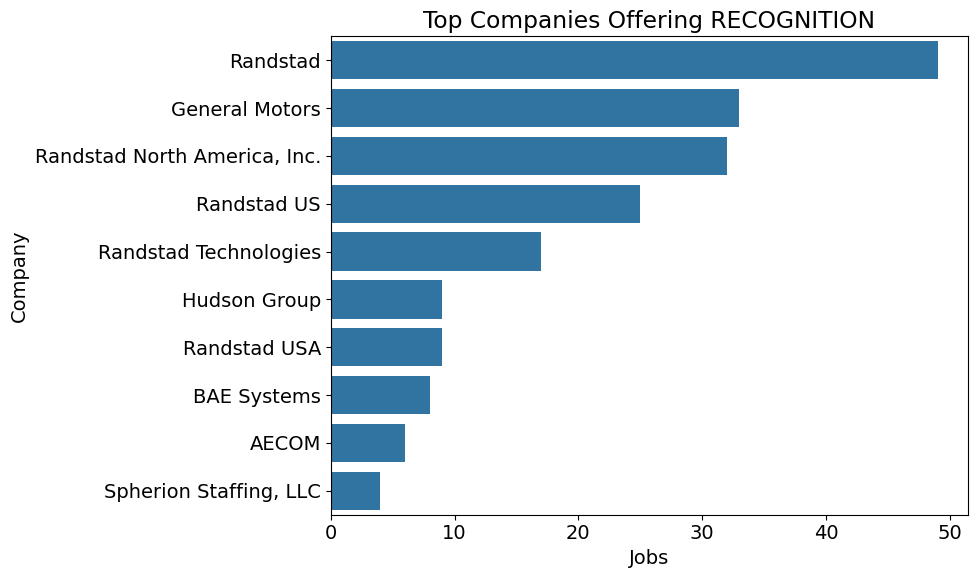

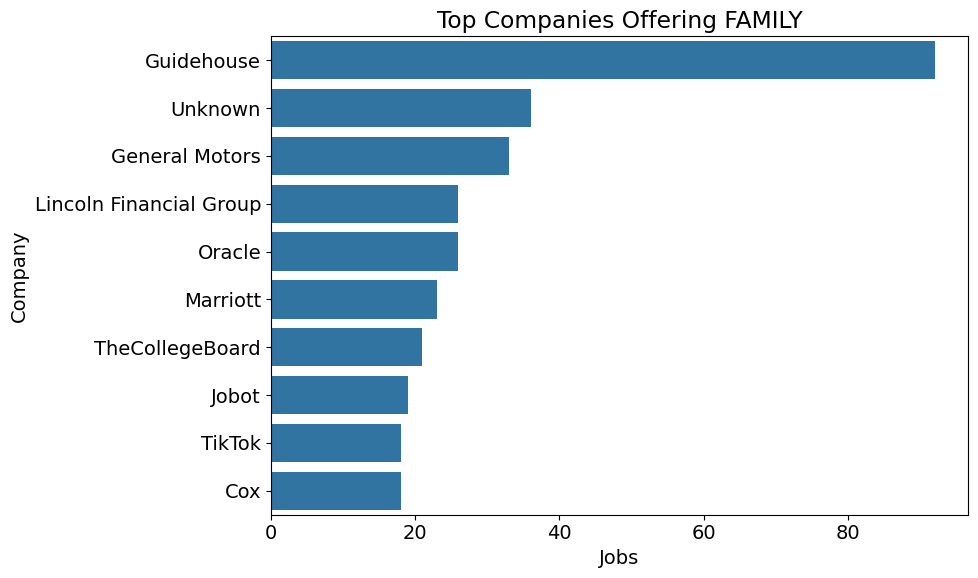

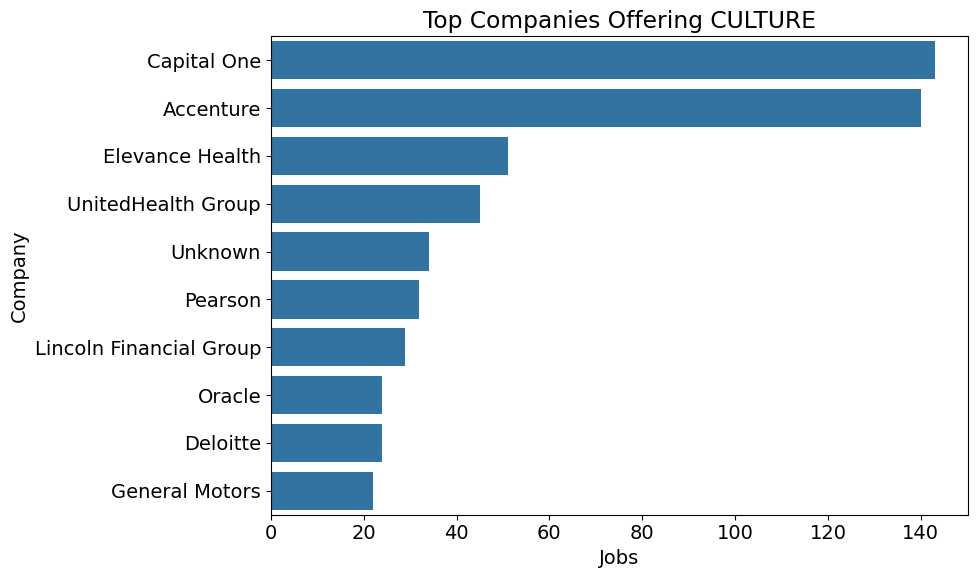

In [174]:
for benefit in benefits:
    benefit_df = even_sample[even_sample[benefit] == True]
    company_count = benefit_df.groupby('COMPANY_RAW').size().sort_values(ascending=False).reset_index()
    # plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=0, y='COMPANY_RAW', data=company_count.head(10))
    plt.xlabel('Jobs')
    plt.ylabel('Company')
    
    plt.title(f'Top Companies Offering {benefit}')
    plt.tight_layout()
    plt.savefig(f'../figures/{benefit}_companies_salary.png')
    print(benefit)
    display(company_count.head(10))

# Benefits by Company and AI Skills

In [176]:
even_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,BLS_NAICS,BLS_industry,CAREER_DEV,WLB,WELLBEING,RECOGNITION,FAMILY,CULTURE,EXPERIENCE_BUCKET,LOG_SALARY
0,b320dcdab94034000293d0c979dafd03543b828b,"San Jose, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,31.0,Manufacturing,False,False,False,False,False,True,3-5 years,12.177416
1,39036fb07ef90297a94c281b153ee88c6d71c514,"Memphis, TN","Shelby, TN",Tennessee,54,"Professional, Scientific, and Technical Services",Master's degree,1,Full-time (> 32 hours),False,...,54.0,Professional and business services,False,True,True,False,False,False,6-10 years,11.813585
2,a81d1896d80873ed098d16225633e2c085c38b5b,"Detroit, MI","Wayne, MI",Michigan,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,...,44.0,Retail trade,False,True,False,False,False,False,None Listed,11.169900
3,1031387a0b167843c4eba97e3d239c9aed4c7e19,"Grand Rapids, MI","Kent, MI",Michigan,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,...,53.0,Financial activities,False,False,False,False,False,False,3-5 years,11.670356
4,85e918411cbf9017505845fb6b9aced339507afb,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,51.0,Information,False,False,False,False,False,False,1-2 years,11.407565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,a52ad16f54d407bdd566fff339ce0538584793f6,"Albany, OR","Linn, OR",Oregon,52,Finance and Insurance,No Education Listed,1,Full-time (> 32 hours),False,...,52.0,Financial activities,False,True,False,False,False,False,None Listed,10.635855
19996,47eead071d7aa1bb7f3e11e10476688deb22e324,"Lithia Springs, GA","Douglas, GA",Georgia,56,Administrative and Support and Waste Managemen...,No Education Listed,1,Full-time (> 32 hours),False,...,56.0,Professional and business services,False,False,False,False,False,False,3-5 years,10.551899
19997,20de39afaee660a555b7d99e8142f5f3906f0a29,"Lufkin, TX","Angelina, TX",Texas,44,Retail Trade,No Education Listed,3,Part-time / full-time,False,...,44.0,Retail trade,True,True,True,False,True,False,None Listed,10.097573
19998,561636d55907d615dcdb24a4ae8fd2777829e767,"Scottsdale, AZ","Maricopa, AZ",Arizona,72,Accommodation and Food Services,No Education Listed,1,Full-time (> 32 hours),False,...,72.0,Leisure and hospitality,True,False,False,False,False,False,1-2 years,10.544288


In [180]:
pd.set_option('display.max_columns', None)

In [181]:
even_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,REMOTE_TYPE,REMOTE_TYPE_NAME,SKILLS,SKILLS_NAME,POSTED,LAST_UPDATED_DATE,ONET,ONET_NAME,ONET_2019,ONET_2019_NAME,SOC_2021_2_NAME,SOC_2021_2,MIN_YEARS_EXPERIENCE,COMPANY,COMPANY_NAME,COMPANY_RAW,AI ROLE,wfh_wham_prob,wfh_wham,YEAR,SALARY,BODY,BLS_NAICS,BLS_industry,CAREER_DEV,WLB,WELLBEING,RECOGNITION,FAMILY,CULTURE,EXPERIENCE_BUCKET,LOG_SALARY
0,b320dcdab94034000293d0c979dafd03543b828b,"San Jose, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS1200364C9C1LK3V5Q1"",\n ""KS1219W70LY1G...","[\n ""C (Programming Language)"",\n ""C++ (Prog...",2023-03-05,2024-03-26,15-2051.00,Data Scientists,15-2051.00,Data Scientists,Computer and Mathematical Occupations,15-0000,5.0,40227665,Viasat,Viasat,True,0.240,0.0,2023,194350.0,Machine Learning Engineer\n Viasat\n\n United ...,31.0,Manufacturing,False,False,False,False,False,True,3-5 years,12.177416
1,39036fb07ef90297a94c281b153ee88c6d71c514,"Memphis, TN","Shelby, TN",Tennessee,54,"Professional, Scientific, and Technical Services",Master's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS126L563YF9Y...","[\n ""Power BI"",\n ""Milestones (Project Manag...",2022-08-18,2024-04-19,13-1111.00,Management Analysts,13-1111.00,Management Analysts,Business and Financial Operations Occupations,13-0000,7.0,5732448,Deloitte,Deloitte,True,0.006,0.0,2022,135075.0,"Manager, People Analytics Deloitte - 3.9 Memph...",54.0,Professional and business services,False,True,True,False,False,False,6-10 years,11.813585
2,a81d1896d80873ed098d16225633e2c085c38b5b,"Detroit, MI","Wayne, MI",Michigan,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS441726FF2HB...","[\n ""Power BI"",\n ""Target Audience"",\n ""Man...",2022-05-27,2024-04-19,15-2051.01,Business Intelligence Analysts,15-2051.01,Business Intelligence Analysts,Computer and Mathematical Occupations,15-0000,NaN,43639907,Dentsu,dentsu,True,0.002,0.0,2022,70962.0,"Careers in Analytics dentsu - 4.3 Detroit, MI ...",44.0,Retail trade,False,True,False,False,False,False,None Listed,11.169900
3,1031387a0b167843c4eba97e3d239c9aed4c7e19,"Grand Rapids, MI","Kent, MI",Michigan,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,1,Remote,"[\n ""KS122CH79G2KSBRRJHTN"",\n ""KS123HX69V95S...","[\n ""Contract Management"",\n ""Performance Ap...",2022-10-27,2024-03-26,11-3061.00,Purchasing Managers,11-3061.00,Purchasing Managers,Management Occupations,11-0000,5.0,6213303,CBRE,CBRE,True,0.959,1.0,2022,117050.0,JOB DETAILS\n\nJob Details\nProcurement Manage...,53.0,Financial activities,False,False,False,False,False,False,3-5 years,11.670356
4,85e918411cbf9017505845fb6b9aced339507afb,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""ES4B99FD0FD70AC92985"",\n ""KS126L563YF9Y...","[\n ""Infrastructure Architecture"",\n ""Milest...",2019-09-16,2024-04-19,15-1251.00,Computer Programmers,15-1251.00,Computer Programmers,Computer and Mathematical Occupations,15-0000,2.0,34817379,Mobile Apps Company,Mobile Apps Company,True,0.043,0.0,2019,90000.0,Posted on\n\nEntry Level Software Programmer\n...,51.0,Information,False,False,False,False,False,False,1-2 years,11.407565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,a52ad16f54d407bdd566fff339ce0538584793f6,"Albany, OR","Linn, OR",Oregon,52,Finance and Insurance,No Education Listed,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS121CT6DCXTRKRJF4RV"",\n ""KS1256K6CCY9P...","[\n ""Capital Requirements"",\n ""Insurance Pro...",2021-03-08,2023-12-14,41-3021.00,Insurance Sales Agents,41-3021.00,Insurance Sales Agents,Sal

In [190]:
for benefit in benefits:
    print(benefit)
    companies_with_benefit = even_sample[even_sample[benefit] == True]['COMPANY_NAME'].unique()
    filtered = even_sample[even_sample['COMPANY_NAME'].isin(companies_with_benefit)]
    display(filtered.groupby(['COMPANY_NAME','AI ROLE',benefit]).size().sort_values())

CAREER_DEV


COMPANY_NAME                   AI ROLE  CAREER_DEV
(Im)Prove                      True     False            1
Noom                           True     True             1
North Dakota State University  True     False            1
                                        True             1
North Wind Group               False    True             1
                                                      ... 
Unclassified                   False    True           242
                               True     True           247
Randstad                       True     False          327
Unclassified                   True     False          666
                               False    False         1231
Length: 2939, dtype: int64

WLB


COMPANY_NAME             AI ROLE  WLB  
#Twiceasnice Recruiting  False    False      1
Okaya                    True     True       1
Okta                     True     False      1
                                  True       1
Old Navy                 False    True       1
                                          ... 
Randstad                 True     False    333
Unclassified             True     True     341
                         False    True     486
                         True     False    572
                         False    False    987
Length: 4566, dtype: int64

WELLBEING


...

COMPANY_NAME             AI ROLE  RECOGNITION
3D Systems               True     True              1
Penske Automotive Group  False    True              1
Owens Corning            True     True              1
                                  False             1
Olmsted County           False    True              1
                                                 ... 
Randstad                 True     True            103
                         False    False           108
                         True     False           236
Unclassified             True     False           910
                         False    False          1462
Length: 146, dtype: int64

FAMILY


COMPANY_NAME                         AI ROLE  FAMILY
1Life Healthcare                     True     True         1
Open Minds Child Development Center  False    True         1
Openlane                             False    True         1
Oracle                               False    False        1
Oregon State University              True     True         1
                                                        ... 
Amazon                               False    False      143
CyberCoders                          True     False      172
Randstad                             True     False      337
Unclassified                         True     False      829
                                     False    False     1416
Length: 1025, dtype: int64

CULTURE


COMPANY_NAME                                              AI ROLE  CULTURE
2020 Companies                                            False    True          1
NYU                                                       False    True          1
NYU Langone Health                                        False    True          1
National Association of County and City Health Officials  True     True          1
National Grid                                             True     True          1
                                                                              ... 
Capital One                                               True     True        150
CyberCoders                                               True     False       171
Randstad                                                  True     False       332
Unclassified                                              True     False       858
                                                          False    False      1431
Length: 1250

# Percent Jobs Offering Benefits per Role Type

In [16]:

# Calculate percentages for each benefit by HAS_AI_SKILLS
percentages = usdf.groupby('AI ROLE')[benefits4].mean() * 100

In [17]:
percentages

,EDU_ASSISTANCE,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,REMOTE_KW
AI ROLE,,,,,,
False,7.337165,24.070093,4.116913,3.065837,8.763338,5.758577
True,6.160445,16.421082,4.358017,6.000281,19.672016,15.845274


In [34]:
for attribute, value in percentages.iterrows():
    print(benefit_colors.get(attribute))

None
None


In [18]:
benefit_colors = {
    'EDU_ASSISTANCE': '#41afaa',
    'PAID_LEAVE': '#466eb4',
    'HEALTH_WELLBEING': '#e6a532',
    'PARENTAL_LEAVE': '#00a0e1',
    'CULTURE': '#d7642c',
    'wfh_wham': '#af4b91', 
    'REMOTE_KW': '#af4b91', 
}

In [41]:
# x = np.arange(len(benefits))
# width = 0.25
# multiplier = 0

# fig, ax = plt.subplots(layout = 'constrained')
# for attribute, value in percentages.iterrows():
#     color = benefit_colors.get(attribute)
#     alpha = 0.7 if False in attribute else 1.0 
#     ax.bar(x + width*multiplier, value, width, label=attribute, color=color, alpha=alpha)
#     multiplier += 1
    
# ax.set_ylabel('Percent of Jobs')
# ax.set_xticks(x+width, benefits4_labels, rotation=45, ha = 'right')
# # set ylim
# ax.set_ylim(0, 40)
# ax.legend(loc = 'upper right', ncols = 2)
# # change legend labels
# ax.legend(['Non-AI Role', 'AI Role'])



In [19]:
# put True row before False in percentages
percentages = percentages.reindex([True, False])

In [20]:
percentages

,EDU_ASSISTANCE,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,REMOTE_KW
AI ROLE,,,,,,
True,6.160445,16.421082,4.358017,6.000281,19.672016,15.845274
False,7.337165,24.070093,4.116913,3.065837,8.763338,5.758577


In [21]:
for i, (role, row) in enumerate(percentages.iterrows()):
    if role == False:
        print("alpha 0.7")

alpha 0.7


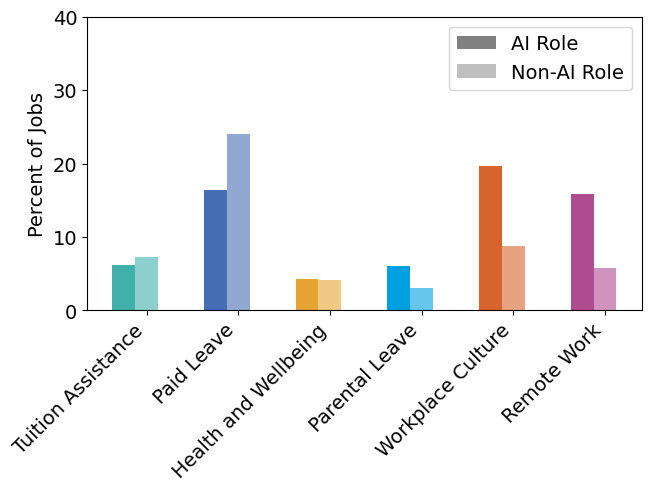

In [23]:
x = np.arange(len(benefits4))
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout = 'constrained')
for i, (role, row) in enumerate(percentages.iterrows()):
    color = [benefit_colors[benefit] for benefit in benefits4]
    alpha = 0.6 if role == False else 1.0
    ax.bar(x + i * width, row[benefits4], width, label=f'AI Role: {role}', color=color, alpha = alpha)
    
ax.set_ylabel('Percent of Jobs')
ax.set_xticks(x+width, benefits4_labels, rotation=45, ha = 'right')
# set ylim
ax.set_ylim(0, 40)
ax.legend(loc = 'upper right', ncols = 2)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray', alpha=1.0, label='AI Role'),
    Patch(facecolor='gray', alpha=0.5, label='Non-AI Role')
]
ax.legend(handles=legend_elements, title=None)
# change legend labels
# ax.legend(['AI Role', 'Non-AI Role'])
plt.savefig('../figures/pct jobs by benefit and role type/benefits_ai_role_colors_10m_2024.png', bbox_inches = 'tight')



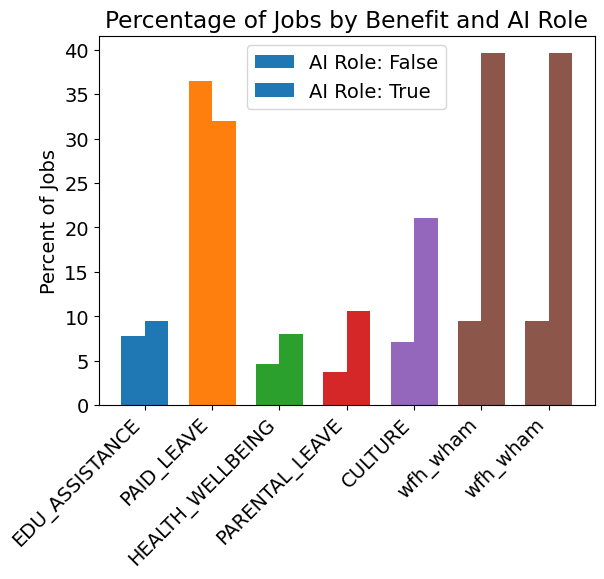

In [42]:
benefit_colors = {
    'EDU_ASSISTANCE': '#1f77b4',  # Blue
    'PAID_LEAVE': '#ff7f0e',      # Orange
    'HEALTH_WELLBEING': '#2ca02c',# Green
    'PARENTAL_LEAVE': '#d62728',  # Red
    'CULTURE': '#9467bd',         # Purple
    'wfh_wham': '#8c564b'         # Brown
}

# Assuming percentages is your DataFrame
x = np.arange(len(benefits))
width = 0.35

fig, ax = plt.subplots()
for i, (role, row) in enumerate(percentages.iterrows()):
    color = [benefit_colors[benefit] for benefit in benefits]
    ax.bar(x + i * width, row, width, label=f'AI Role: {role}', color=color)

ax.set_ylabel('Percent of Jobs')
ax.set_title('Percentage of Jobs by Benefit and AI Role')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(benefits, rotation=45, ha='right')
ax.legend()

plt.show()

## WHAM Sample

In [52]:
wham_even_sample = pd.read_parquet('../data/small_samples/salary_wham_sample_20k.parquet.gzip')

In [53]:
benefits = benefits4+['wfh_wham']

In [68]:

# Calculate percentages for each benefit by HAS_AI_SKILLS
percentages = wham_even_sample.groupby('AI ROLE')[benefits].mean() * 100

In [69]:
percentages

,EDU_ASSISTANCE,WLB,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,wfh_wham
AI ROLE,,,,,,,
False,7.76,38.15,37.20,5.39,3.97,7.84,9.57
True,9.90,34.63,32.75,8.66,10.92,22.13,38.45


In [70]:
benefits_labels = "Tuition Assistance", "Work-Life Balance", "Paid Vacation", "Health & Wellbeing", "Parental Leave", "Inclusive Culture", "Remote Work"

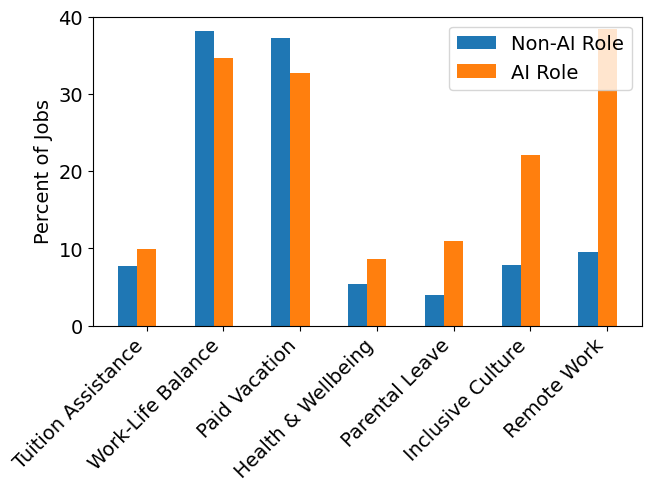

In [71]:
x = np.arange(len(benefits))
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout = 'constrained')
for attribute, value in percentages.iterrows():
    ax.bar(x + width*multiplier, value, width, label=attribute)
    multiplier += 1
    
ax.set_ylabel('Percent of Jobs')
ax.set_xticks(x+width, benefits_labels, rotation=45, ha = 'right')
ax.set_ylim(0, 40)
ax.legend(loc = 'upper right', ncols = 2)

# change legend labels
ax.legend(['Non-AI Role', 'AI Role'])



## No Salary Sample

In [35]:
even_sample_nosal = pd.read_parquet('../data/small_samples/nosalary_sample_20k.parquet.gzip')

In [76]:

# Calculate percentages for each benefit by HAS_AI_SKILLS
percentages = even_sample_nosal.groupby('AI ROLE')[benefits].mean() * 100

In [77]:
percentages

,EDU_ASSISTANCE,WLB,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,wfh_wham
AI ROLE,,,,,,,
False,7.76,25.22,24.12,4.02,2.92,9.40,7.62
True,6.12,18.19,16.37,4.71,6.20,20.57,23.64


In [78]:
benefits_labels = "Tuition Assistance", "Work-Life Balance", "Paid Vacation", "Health & Wellbeing", "Parental Leave", "Inclusive Culture", "Remote Work"

In [79]:
len(benefits)

7

In [80]:
len(benefits_labels)

7

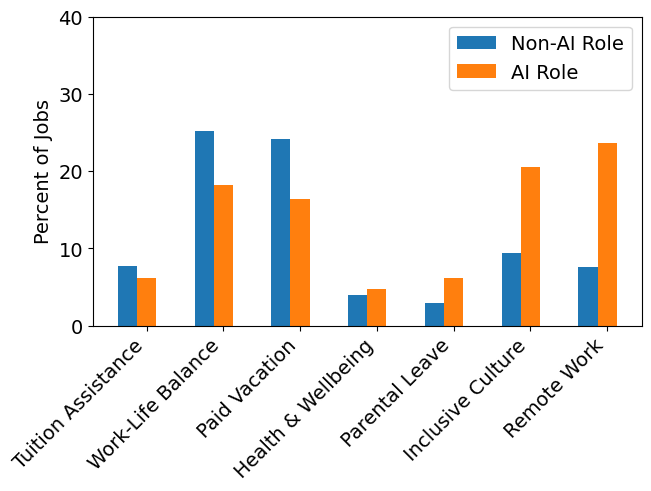

In [81]:
x = np.arange(len(benefits))
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout = 'constrained')
for attribute, value in percentages.iterrows():
    ax.bar(x + width*multiplier, value, width, label=attribute)
    multiplier += 1
    
ax.set_ylabel('Percent of Jobs')
ax.set_xticks(x+width, benefits_labels, rotation=45, ha = 'right')
ax.set_ylim(0, 40)
ax.legend(loc = 'upper right', ncols = 2)

# change legend labels
ax.legend(['Non-AI Role', 'AI Role'])



# Benefits by Occupation & Role Type

In [188]:
occupations_select = ['Architecture and Engineering Occupations','Arts, Design, Entertainment, Sports, and Media Occupations','Business and Financial Operations Occupations','Community and Social Service Occupations','Computer and Mathematical Occupations',
'Educational Instruction and Library Occupations',
'Healthcare Practitioners and Technical Occupations',
'Legal Occupations',
'Life, Physical, and Social Science Occupations',
'Management Occupations', 
'Office and Administrative Support Occupations',
'Personal Care and Service Occupations', 'Production Occupations',
'Sales and Related Occupations',
'Transportation and Material Moving Occupations',
]

In [189]:
usdf_select = usdf[usdf[occupation].isin(occupations_select)]

In [190]:
def get_benefit_by_occupation(usdf_select, benefit):
    occ_ai_benefit_group = usdf_select.groupby([occupation, 'AI ROLE',benefit]).size().reset_index(name='benefit_count')
    occ_ai_group = usdf_select.groupby([occupation, 'AI ROLE']).size().reset_index(name='count')
    occ_ai_benefit_group = occ_ai_benefit_group.merge(occ_ai_group, on = ['SOC_2021_2_NAME','AI ROLE'], how = 'left')
    occ_ai_benefit_group[f'Percent with {benefit}'] = occ_ai_benefit_group['benefit_count']/occ_ai_benefit_group['count']
    occ_ai_benefit_percent = occ_ai_benefit_group[occ_ai_benefit_group[benefit] == 1.0].copy()
    # rename columns without setting copy of a slice
    
    
    occ_ai_benefit_percent.rename(columns = {'SOC_2021_2_NAME': 'Occupation'}, inplace=True)
    occ_ai_benefit_percent['AI ROLE'] = occ_ai_benefit_percent['AI ROLE'].map({True: 'Yes', False: 'No'})
    occ_ai_benefit_percent['Occupation'] = occ_ai_benefit_percent['Occupation'].str.replace(' Occupations', '')

    return occ_ai_benefit_percent
    

In [191]:
benefit_percent_dfs = []
for benefit in benefits4:
    occ_ai_benefit_percent = get_benefit_by_occupation(usdf_select, benefit)
    benefit_percent_dfs.append(occ_ai_benefit_percent)

In [192]:
occ_ai_benefit_percent

,Occupation,AI ROLE,REMOTE_KW,benefit_count,count,Percent with REMOTE_KW
1,Architecture and Engineering,No,True,15021,213408,0.070386
3,Architecture and Engineering,Yes,True,504,4637,0.108691
5,"Arts, Design, Entertainment, Sports, and Media",No,True,15363,211606,0.072602
7,"Arts, Design, Entertainment, Sports, and Media",Yes,True,535,2045,0.261614
9,Business and Financial Operations,No,True,87804,703856,0.124747
11,Business and Financial Operations,Yes,True,2086,13336,0.156419
13,Community and Social Service,No,True,15336,181744,0.084382
15,Community and Social Service,Yes,True,60,429,0.139860
17,Computer and Mathematical,No,True,110106,767889,0.143388
19,Computer and Mathematical,Yes,True,11594,70307,0.164905


In [193]:
usdf_select['YEAR'].unique()

array([2019, 2021, 2018, 2022, 2020, 2023, 2024], dtype=int32)

In [107]:
benefit_colors

{'EDU_ASSISTANCE': '#41afaa',
 'PAID_LEAVE': '#466eb4',
 'HEALTH_WELLBEING': '#e6a532',
 'PARENTAL_LEAVE': '#00a0e1',
 'CULTURE': '#d7642c',
 'wfh_wham': '#af4b91',
 'REMOTE_KW': '#af4b91'}

In [154]:
benefit_colors_2 = benefit_colors.copy()

In [155]:
for i, (benefit, color) in enumerate(benefit_colors_2.items()):
    benefit_colors_2[benefit] = [benefit_colors_2[benefit], lightened_colors[i]]

In [156]:
benefit_colors_2

{'EDU_ASSISTANCE': ['#41afaa', '#b3dfdd'],
 'PAID_LEAVE': ['#466eb4', '#b5c5e1'],
 'HEALTH_WELLBEING': ['#e6a532', '#f5dbad'],
 'PARENTAL_LEAVE': ['#00a0e1', '#99d9f3'],
 'CULTURE': ['#d7642c', '#efc1ab'],
 'wfh_wham': ['#af4b91', '#dfb7d3'],
 'REMOTE_KW': ['#af4b91', '#dfb7d3']}

In [129]:
colors_list = list(benefit_colors.values())

In [131]:
from matplotlib.colors import to_rgb, to_hex

In [132]:
lightened_colors = [lighten_color(color, blend_factor=0.6) for color in colors_list]

In [127]:
def lighten_color(hex_color, blend_factor=0.6):
    # Convert hex to RGB
    rgb = to_rgb(hex_color)
    # Blend with white
    light_rgb = [(1 - blend_factor) * channel + blend_factor for channel in rgb]
    # Convert back to hex
    return to_hex(light_rgb)

In [108]:
to_rgba('#41afaa', 0.6)

(0.2549019607843137, 0.6862745098039216, 0.6666666666666666, 0.6)

In [123]:
def add_alpha_to_hex(hex_color, alpha):
    # Convert hex color to RGBA
    rgba = to_rgba(hex_color, alpha)
    # Convert to hex format with alpha
    hex_with_alpha = '#{:02x}{:02x}{:02x}{:02x}'.format(
        int(rgba[0] * 255),
        int(rgba[1] * 255),
        int(rgba[2] * 255),
        int(rgba[3] * 255)
    )
    return hex_with_alpha

In [124]:
add_alpha_to_hex('#41afaa', 0.6)

'#41afaa99'

In [111]:
from matplotlib.colors import to_rgba
def plot_benefit_occ_percents(df, benefit):
    sorted_data = df[df['AI ROLE'] == 'No']
    sorted_data = sorted_data.sort_values(by=f'Percent with {benefit}', ascending=True)
    color = benefit_colors[benefit]
    palette = {'Yes': to_rgba(color, 1),
               'No': to_rgba((color[0]*0.9, color[1]*0.9, color[2]*0.9), 0.6)}
    print(palette)
    alpha = 0.6 if role == False else 1.0
    # Create a figure and axis object
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot the data as a clustered bar chart
    sns.barplot(x=f'Percent with {benefit}', y='Occupation', hue='AI ROLE', data=df, ax=ax, palette=palette)

    # Set the labels and title
    ax.set_xlabel(f'Percent Jobs with {benefits_labels_map[benefit]}', fontsize=14)
    ax.set_ylabel('Occupation', fontsize=14)
    ax.set_title(None)

    # Add value labels without decimals
    # for p in ax.patches:
    #     width = p.get_width()
    #     ax.annotate(f'{width:.1f}%', (p.get_x() + p.get_width(), p.get_y() + p.get_height() / 2.),
    #                 ha='center', va='center', fontsize=12, color='black', xytext=(5, 0),
    #                 textcoords='offset points')

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Adjust the legend position and title
    plt.legend(title='AI ROLE', bbox_to_anchor=(1.02, 1), loc='upper left')

    # Adjust spacing between subplots
    plt.subplots_adjust(bottom=0.2, left=0.1, right=0.9, top=0.9)
    plt.tight_layout()
    # plt.savefig(f'../figures/percent_by_occupation_{benefit}_even_sample.png')
    # Show the plot
    plt.show()

In [112]:
for df, benefit in zip(benefit_percent_dfs, benefits4):
    plot_benefit_occ_percents(df, benefit)

TypeError: can't multiply sequence by non-int of type 'float'

In [96]:
def plot_benefit_occ_percents(df, benefit):
    sorted_data = df[df['AI ROLE'] == 'No']
    sorted_data = sorted_data.sort_values(by=f'Percent with {benefit}', ascending=True)
    color = benefit_colors[benefit]

    # Create a figure and axis object
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot the data as a clustered bar chart with same color and varying alpha for AI ROLE categories
    for ai_role, alpha in zip(['No', 'Yes'], [0.6, 1.0]):
        sns.barplot(
            x=f'Percent with {benefit}', y='Occupation',
            data=df[df['AI ROLE'] == ai_role],
            ax=ax, color=color, alpha=alpha,
            label=ai_role
        )

    # Set the labels and title
    ax.set_xlabel(f'Percent Jobs with {benefits_labels_map[benefit]}', fontsize=14)
    ax.set_ylabel('Occupation', fontsize=14)
    ax.set_title(None)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Adjust the legend position and title
    plt.legend(title='AI ROLE', bbox_to_anchor=(1.02, 1), loc='upper left')

    # Adjust spacing between subplots
    plt.subplots_adjust(bottom=0.2, left=0.1, right=0.9, top=0.9)
    plt.tight_layout()

    # Show the plot
    plt.show()


In [94]:
def plot_benefit_occ_percents(df, benefit):
    sorted_data = df.sort_values(by=f'Percent with {benefit}', ascending=True)
    color = benefit_colors[benefit]

    # Create a figure and axis object
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot 'No' AI ROLE category
    sns.barplot(
        x=f'Percent with {benefit}', y='Occupation', 
        data=df[df['AI ROLE'] == 'No'],
        ax=ax, color=color, alpha=0.6, label='No'
    )

    # Plot 'Yes' AI ROLE category
    sns.barplot(
        x=f'Percent with {benefit}', y='Occupation', 
        data=df[df['AI ROLE'] == 'Yes'],
        ax=ax, color=color, alpha=1.0, label='Yes'
    )

    # Set the labels and title
    ax.set_xlabel(f'Percent Jobs with {benefits_labels_map[benefit]}', fontsize=14)
    ax.set_ylabel('Occupation', fontsize=14)
    ax.set_title(None)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Adjust the legend position and title
    plt.legend(title='AI ROLE', bbox_to_anchor=(1.02, 1), loc='upper left')

    # Adjust spacing between subplots
    plt.subplots_adjust(bottom=0.2, left=0.1, right=0.9, top=0.9)
    plt.tight_layout()

    # Show the plot
    plt.show()


In [144]:
benefit_colors_2['wfh_wham']

['#af4b91#dfb7d3', '#dfb7d3']

In [180]:
usdf['YEAR'].unique()

array([2019, 2021, 2022, 2020, 2018, 2023], dtype=int32)

## Final Plot

In [194]:
from matplotlib.colors import to_rgba

def plot_benefit_occ_percents(df, benefit):
    sorted_data = df[df['AI ROLE'] == 'No']

    # Sort data for better visualization
    sorted_data = sorted_data.sort_values(by=['AI ROLE',f'Percent with {benefit}'], ascending=[False, True])
    # color = benefit_colors[benefit]
    df = df.sort_values(by=['AI ROLE', f'Percent with {benefit}'], ascending=[False, True])
    # Create a custom palette using the same color with different alpha values
    palette = benefit_colors_2[benefit]

    # Create a figure and axis object
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot the data with the custom palette, distinguishing AI ROLE by hue
    sns.barplot(
        x=f'Percent with {benefit}', y='Occupation', hue='AI ROLE', 
        data=df, ax=ax, palette=palette, dodge=True, order=sorted_data['Occupation']
    )

    # Set the labels and title
    ax.set_xlabel(f'Percent Jobs with {benefits_labels_map[benefit]}', fontsize=14)
    ax.set_ylabel('Occupation', fontsize=14)
    ax.set_title(None)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Adjust the legend position and title
    plt.legend(title='AI ROLE', bbox_to_anchor=(1.02, 1), loc='upper left')

    # Adjust spacing between subplots
    plt.subplots_adjust(bottom=0.2, left=0.1, right=0.9, top=0.9)
    plt.tight_layout()
    plt.savefig(f'../figures/percent_by_occupation_colors_2024_{benefit}.png')
    # Show the plot
    plt.show()


In [195]:
# set font size
plt.rcParams.update({'font.size': 14})

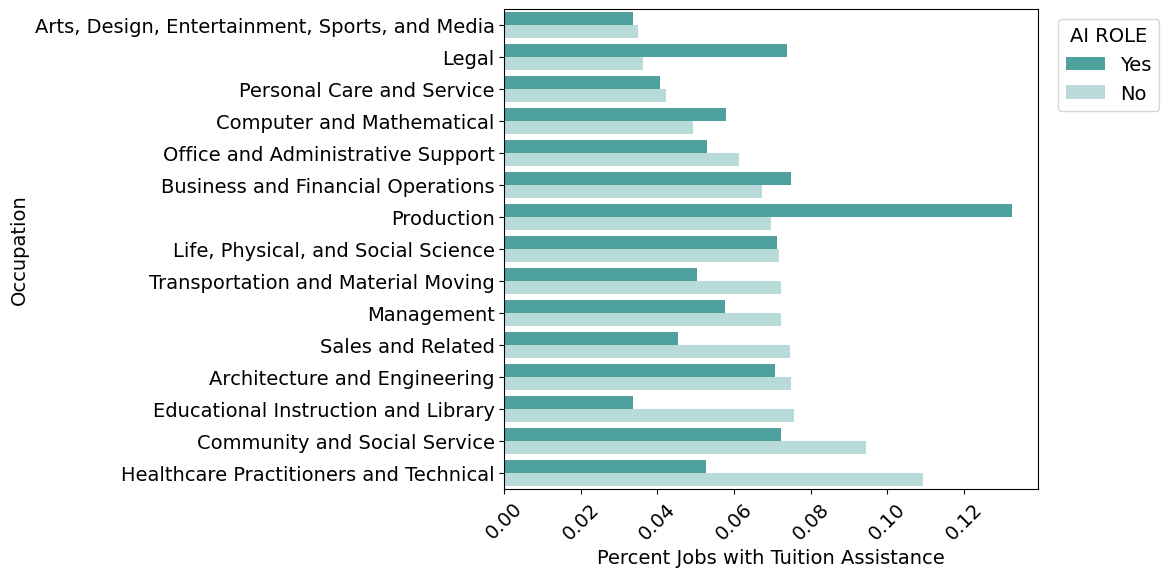

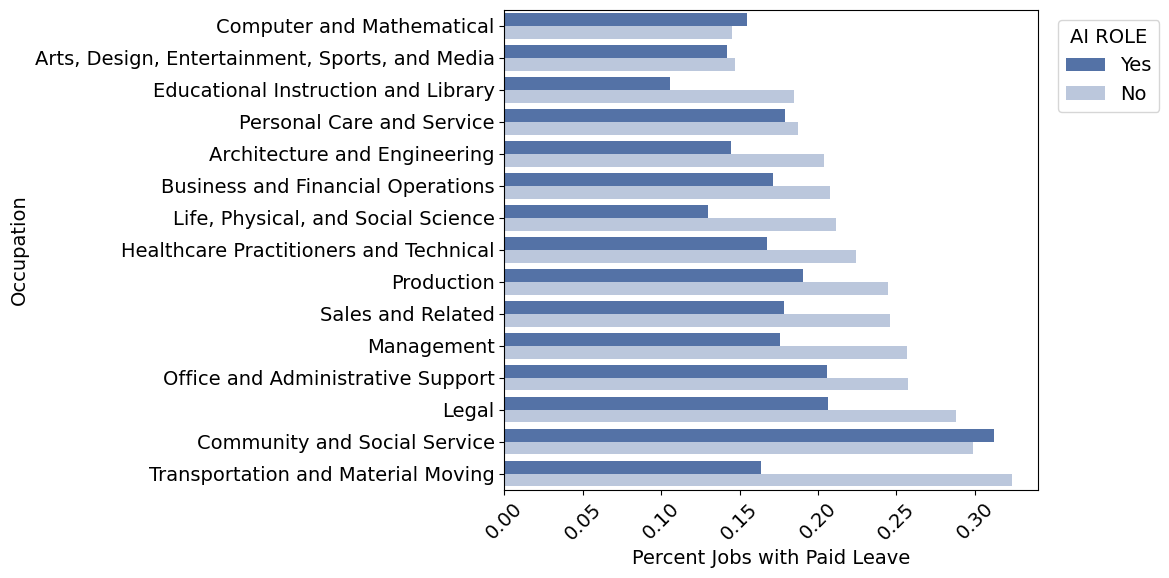

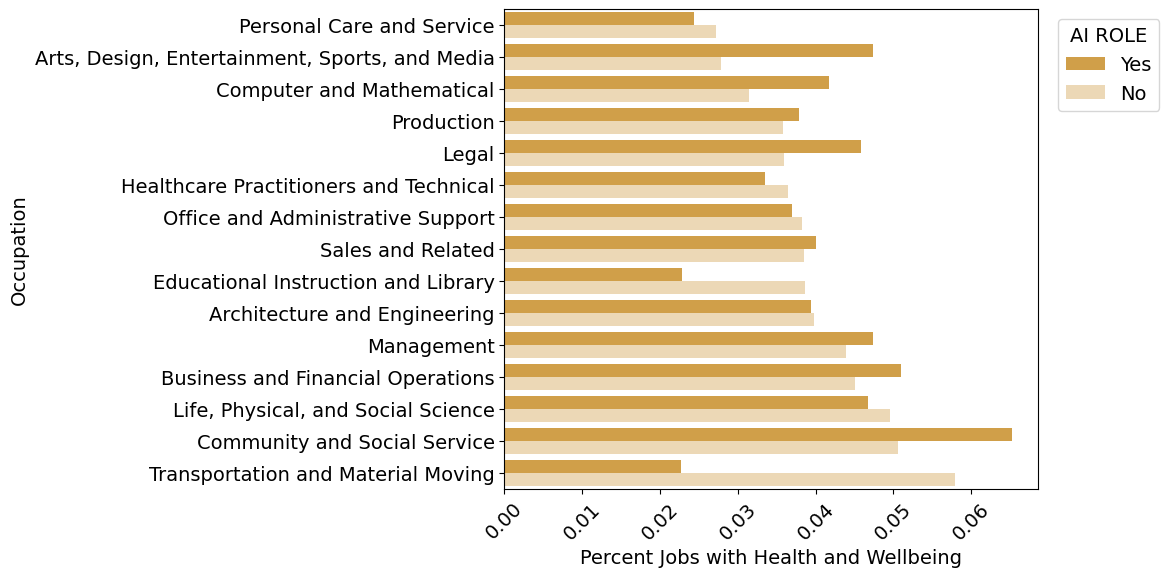

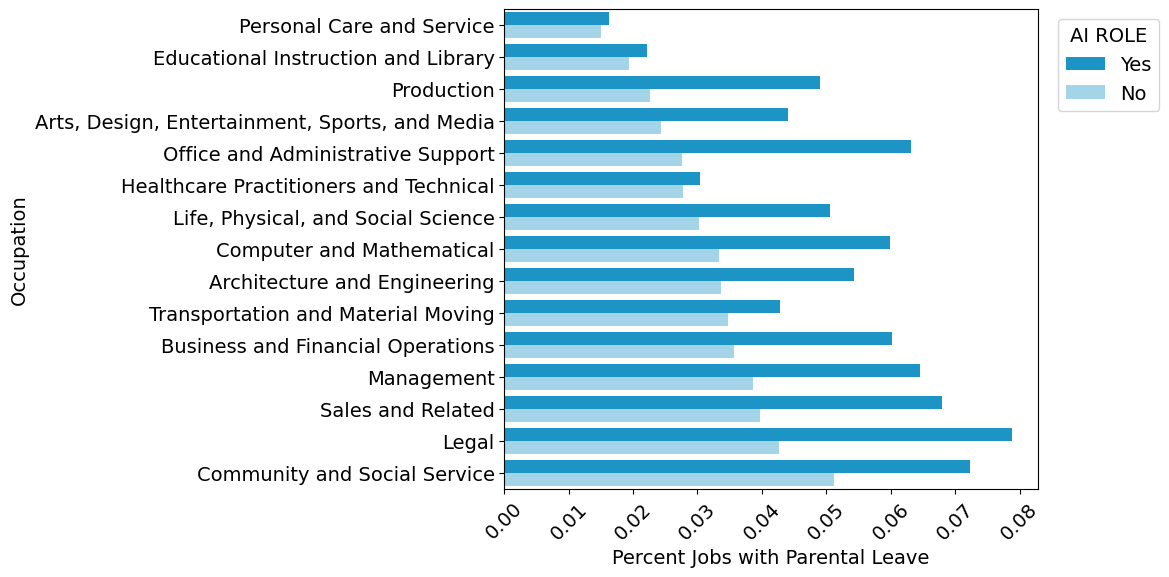

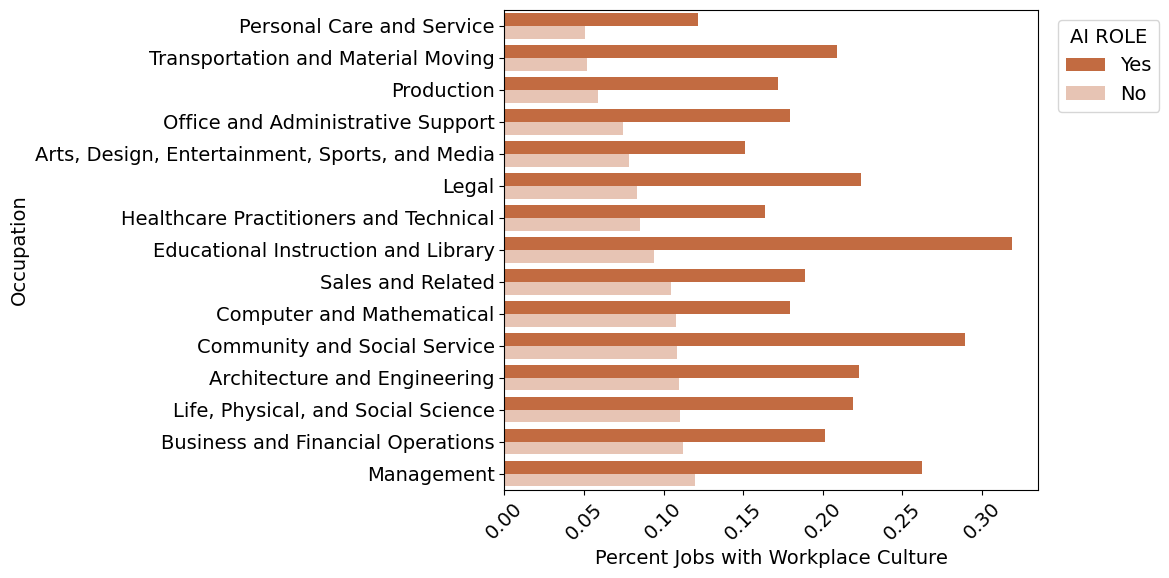

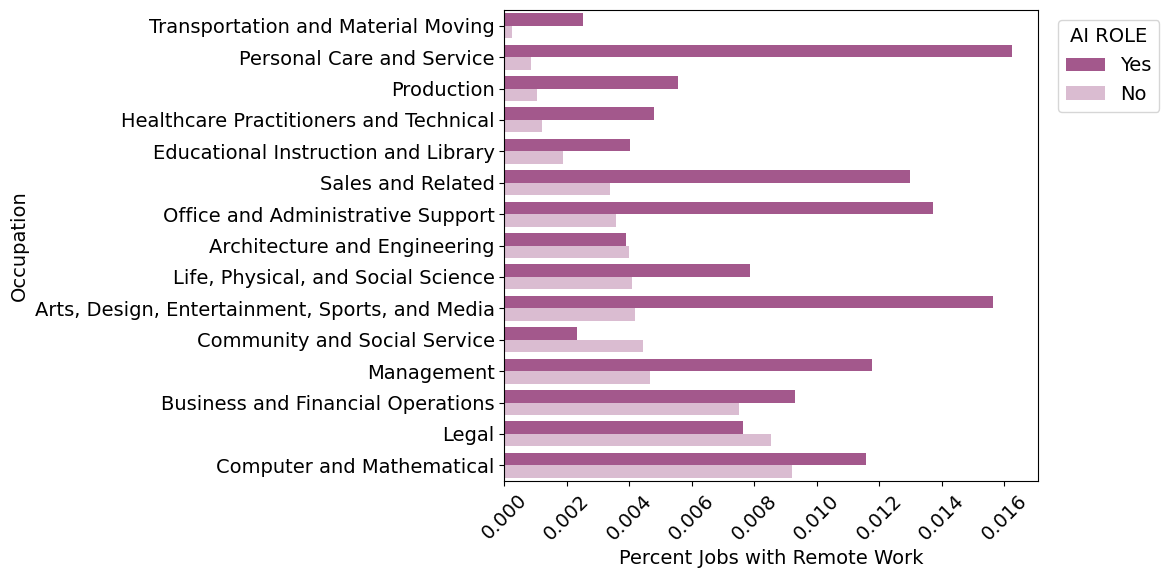

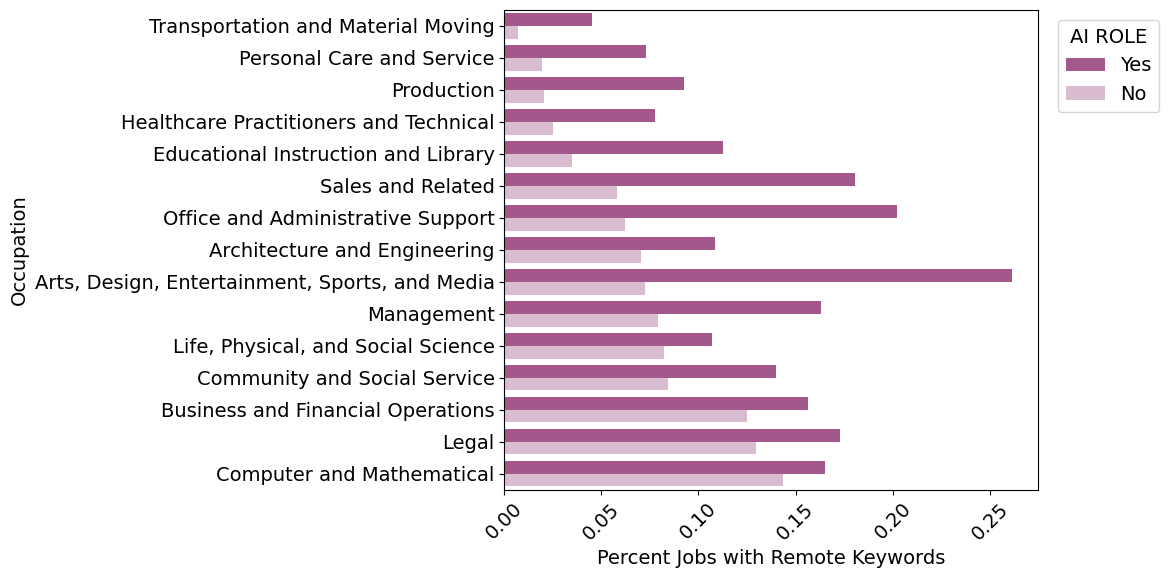

In [196]:
for df, benefit in zip(benefit_percent_dfs, benefits4):
    plot_benefit_occ_percents(df, benefit)